In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication configured.")

Kaggle authentication configured.


In [ ]:
!pip -q install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.9 MB/s eta 0:00:00


In [ ]:
!kaggle datasets files -d moritzm00/utkface-cropped

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U4Jiomr4alAJrda9RdT91MxixoFleaCcKJETmU5sQZmVAkgOd2xUA_AGvKYVF3btJuwMrj_TXAgNXncuqa3MmBVxVM39koRndU36yEgfryh_MMtaI5O-HtgNdZu-vE_-EokQZRrGBop7rxItCPeKStbCX3HKA
name                                            size  creationDate                
----------------------------------------------  ----  --------------------------  
UTKFace/100_0_0_20170112213500903.jpg.chip.jpg  7916  2023-04-16 11:41:15.779000  
UTKFace/100_0_0_20170112215240346.jpg.chip.jpg  7208  2023-04-16 11:40:58.068000  
UTKFace/100_1_0_20170110183726390.jpg.chip.jpg  9018  2023-04-16 11:41:06.655000  
UTKFace/100_1_0_20170112213001988.jpg.chip.jpg  7184  2023-04-16 11:41:13.688000  
UTKFace/100_1_0_20170112213303693.jpg.chip.jpg  7631  2023-04-16 11:41:12.960000  
UTKFace/100_1_0_20170112215032192.jpg.chip.jpg  5134  2023-04-16 11:40:54.738000  
UTKFace/100_1_0_20170117195420803.jpg.chip.jpg  5853  2023-04-16 11:41:11.324000  
UTKFace/100_1_0_20170119212053665.jpg.chip.jpg  6740

In [ ]:
!mkdir -p /content/dataset
!kaggle datasets download -d moritzm00/utkface-cropped -p /content/dataset

Dataset URL: https://www.kaggle.com/datasets/moritzm00/utkface-cropped
License(s): unknown
100% 116M/116M [00:01<00:00, 115MB/s]



In [ ]:
!ls -lh /content/dataset

total 116M
-rw-r--r-- 1 root root 116M Apr 16  2023 utkface-cropped.zip


In [ ]:
!mkdir -p /content/UTKFace
!unzip -q /content/dataset/utkface-cropped.zip -d /content/UTKFace

In [ ]:
!find /content/UTKFace -type f | head -10

/content/UTKFace/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg
/content/UTKFace/UTKFace/100_0_0_20170112215240346.jpg.chip.jpg
/content/UTKFace/UTKFace/100_1_0_20170110183726390.jpg.chip.jpg
/content/UTKFace/UTKFace/100_1_0_20170112213001988.jpg.chip.jpg
/content/UTKFace/UTKFace/100_1_0_20170112213303693.jpg.chip.jpg
/content/UTKFace/UTKFace/100_1_0_20170112215032192.jpg.chip.jpg
/content/UTKFace/UTKFace/100_1_0_20170117195420803.jpg.chip.jpg
/content/UTKFace/UTKFace/100_1_0_20170119212053665.jpg.chip.jpg
/content/UTKFace/UTKFace/100_1_2_20170105174847679.jpg.chip.jpg
/content/UTKFace/UTKFace/100_1_2_20170112213615815.jpg.chip.jpg


In [ ]:
import os

data_dir = "/content/UTKFace/UTKFace"

image_files = [
    f for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images:", len(image_files))

Total images: 23708


In [ ]:
import os
from PIL import Image

data_dir = "/content/UTKFace/UTKFace"

image_files = [
    f for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Extract ages from filenames
ages = [int(f.split("_")[0]) for f in image_files]

print("Total images:", len(image_files))
print("Minimum age:", min(ages))
print("Maximum age:", max(ages))
print("First 10 ages:", ages[:10])

# Check one image
sample_file = os.path.join(data_dir, image_files[0])
img = Image.open(sample_file)

print("\nSample image:", image_files[0])
print("Image size:", img.size)
print("Image mode:", img.mode)

Total images: 23708
Minimum age: 1
Maximum age: 116
First 10 ages: [31, 28, 54, 58, 26, 54, 28, 26, 37, 29]

Sample image: 31_0_2_20170116193441821.jpg.chip.jpg
Image size: (200, 200)
Image mode: RGB


In [ ]:
import os
import random

data_dir = "/content/UTKFace/UTKFace"

image_files = [
    f for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Fixed seed for reproducibility
random.seed(42)
random.shuffle(image_files)

# Split sizes
n = len(image_files)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_files = image_files[:train_end]
val_files = image_files[train_end:val_end]
test_files = image_files[val_end:]

print("Total images:", n)
print("Training images:", len(train_files))
print("Validation images:", len(val_files))
print("Testing images:", len(test_files))

Total images: 23708
Training images: 16595
Validation images: 3556
Testing images: 3557


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Dataset class
class UTKFaceDataset(Dataset):
    def __init__(self, file_list, data_dir, transform=None):
        self.file_list = file_list
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]
        image_path = os.path.join(self.data_dir, filename)

        image = Image.open(image_path).convert("RGB")

        # Age is the first number in the filename
        age = float(filename.split("_")[0])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(age, dtype=torch.float32)


# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transformations
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Create datasets
train_dataset = UTKFaceDataset(
    train_files, data_dir, train_transform
)

val_dataset = UTKFaceDataset(
    val_files, data_dir, test_transform
)

test_dataset = UTKFaceDataset(
    test_files, data_dir, test_transform
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 260
Validation batches: 56
Test batches: 56


In [ ]:
images, ages = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Age batch shape:", ages.shape)
print("First 10 ages:", ages[:10].tolist())

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images = images.to(device)
ages = ages.to(device)

print("Device:", device)
print("Images on:", images.device)
print("Ages on:", ages.device)

NameError: name 'train_loader' is not defined

Input Image (224×224)
        ↓
Convolution Blocks
        ↓
Feature Extraction
        ↓
Global Average Pooling
        ↓
Fully Connected Layer
        ↓
Predicted Age

In [ ]:
import torch
import torch.nn as nn

class CNNAgeRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x.squeeze(1)


# Create model
cnn_model = CNNAgeRegressor().to(device)

print(cnn_model)

CNNAgeRegressor(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats

Model 1 has been created successfully.

Input: 224×224×3
      ↓
Conv 3 → 32
      ↓
Conv 32 → 64
      ↓
Conv 64 → 128
      ↓
Conv 128 → 256
      ↓
Global Average Pooling
      ↓
256 → 128
      ↓
128 → 1
      ↓
Predicted Age

In [ ]:
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(
    p.numel() for p in cnn_model.parameters() if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Parameters (millions):", total_params / 1e6)

Total parameters: 422401
Trainable parameters: 422401
Parameters (millions): 0.422401


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import math

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": []
    }

    start_time = time.time()

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        train_loss = 0.0
        train_abs_error = 0.0
        train_count = 0

        for images, ages in train_loader:
            images = images.to(device, non_blocking=True)
            ages = ages.to(device, non_blocking=True)

            optimizer.zero_grad()

            predictions = model(images)

            loss = criterion(predictions, ages)

            loss.backward()
            optimizer.step()

            batch_size = images.size(0)

            train_loss += loss.item() * batch_size
            train_abs_error += torch.sum(
                torch.abs(predictions - ages)
            ).item()

            train_count += batch_size

        train_loss /= train_count
        train_mae = train_abs_error / train_count

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        val_loss = 0.0
        val_abs_error = 0.0
        val_count = 0

        with torch.no_grad():
            for images, ages in val_loader:
                images = images.to(device, non_blocking=True)
                ages = ages.to(device, non_blocking=True)

                predictions = model(images)

                loss = criterion(predictions, ages)

                batch_size = images.size(0)

                val_loss += loss.item() * batch_size
                val_abs_error += torch.sum(
                    torch.abs(predictions - ages)
                ).item()

                val_count += batch_size

        val_loss /= val_count
        val_mae = val_abs_error / val_count

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train MAE: {train_mae:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val MAE: {val_mae:.4f}"
        )

    training_time = time.time() - start_time

    print(f"\nTraining time: {training_time/60:.2f} minutes")

    return model, history, training_time

In [ ]:
cnn_model, cnn_history, cnn_training_time = train_model(
    cnn_model,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-4
)

Epoch [1/10] | Train Loss: 794.3389 | Train MAE: 22.0291 | Val Loss: 285.1940 | Val MAE: 12.6482
Epoch [2/10] | Train Loss: 279.1644 | Train MAE: 12.7731 | Val Loss: 260.9815 | Val MAE: 13.0349
Epoch [3/10] | Train Loss: 256.2895 | Train MAE: 12.3142 | Val Loss: 232.0612 | Val MAE: 12.0037
Epoch [4/10] | Train Loss: 248.4462 | Train MAE: 12.1497 | Val Loss: 218.6510 | Val MAE: 11.5371
Epoch [5/10] | Train Loss: 241.0769 | Train MAE: 11.9897 | Val Loss: 231.3822 | Val MAE: 11.6715
Epoch [6/10] | Train Loss: 232.4583 | Train MAE: 11.7872 | Val Loss: 220.4528 | Val MAE: 11.4305
Epoch [7/10] | Train Loss: 227.3758 | Train MAE: 11.6660 | Val Loss: 220.0384 | Val MAE: 11.4887
Epoch [8/10] | Train Loss: 227.1013 | Train MAE: 11.6674 | Val Loss: 207.2956 | Val MAE: 11.0563
Epoch [9/10] | Train Loss: 222.6136 | Train MAE: 11.5073 | Val Loss: 273.8059 | Val MAE: 13.4853
Epoch [10/10] | Train Loss: 214.3835 | Train MAE: 11.2866 | Val Loss: 195.8919 | Val MAE: 10.8009

Training time: 14.80 minutes

In [ ]:
import torch
import numpy as np
import time

def evaluate_model(model, test_loader):
    model.eval()

    predictions = []
    actuals = []

    start_time = time.time()

    with torch.no_grad():
        for images, ages in test_loader:
            images = images.to(device, non_blocking=True)

            outputs = model(images)

            predictions.extend(outputs.cpu().numpy())
            actuals.extend(ages.numpy())

    inference_time = time.time() - start_time

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    mae = np.mean(np.abs(predictions - actuals))
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))

    return mae, rmse, predictions, actuals, inference_time


cnn_mae, cnn_rmse, cnn_predictions, cnn_actuals, cnn_inference_time = evaluate_model(
    cnn_model,
    test_loader
)

print("CNN Test MAE:", round(cnn_mae, 4))
print("CNN Test RMSE:", round(cnn_rmse, 4))
print("CNN Test Inference Time:", round(cnn_inference_time, 2), "seconds")

CNN Test MAE: 10.9557
CNN Test RMSE: 14.33
CNN Test Inference Time: 9.1 seconds


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# Load ImageNet-pretrained ConvNeXt-Tiny
weights = ConvNeXt_Tiny_Weights.DEFAULT
convnext_model = convnext_tiny(weights=weights)

# Replace classification head for age regression
in_features = convnext_model.classifier[2].in_features

convnext_model.classifier[2] = nn.Linear(in_features, 1)

# Move to GPU
convnext_model = convnext_model.to(device)

print(convnext_model)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 130MB/s] 


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [ ]:
total_params = sum(p.numel() for p in convnext_model.parameters())
trainable_params = sum(
    p.numel() for p in convnext_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Parameters (millions):", total_params / 1e6)

Total parameters: 27820897
Trainable parameters: 27820897
Parameters (millions): 27.820897


In [ ]:
convnext_model, convnext_history, convnext_training_time = train_model(
    convnext_model,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-5
)

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([19])) that is different to the input size (torch.Size([19, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/10] | Train Loss: 940.6693 | Train MAE: 1591.6191 | Val Loss: 726.5026 | Val MAE: 1367.3099


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([36])) that is different to the input size (torch.Size([36, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [2/10] | Train Loss: 716.7590 | Train MAE: 1355.2205 | Val Loss: 669.5400 | Val MAE: 1297.6854
Epoch [3/10] | Train Loss: 659.6833 | Train MAE: 1284.5629 | Val Loss: 621.1866 | Val MAE: 1235.0193
Epoch [4/10] | Train Loss: 611.5350 | Train MAE: 1222.1703 | Val Loss: 577.8860 | Val MAE: 1175.6630
Epoch [5/10] | Train Loss: 569.4835 | Train MAE: 1163.0485 | Val Loss: 539.7408 | Val MAE: 1119.4955
Epoch [6/10] | Train Loss: 532.7164 | Train MAE: 1109.2163 | Val Loss: 506.7037 | Val MAE: 1068.6316
Epoch [7/10] | Train Loss: 501.0741 | Train MAE: 1060.2027 | Val Loss: 478.6290 | Val MAE: 1023.7255
Epoch [8/10] | Train Loss: 474.4635 | Train MAE: 1018.4966 | Val Loss: 455.2285 | Val MAE: 986.5105
Epoch [9/10] | Train Loss: 452.6577 | Train MAE: 986.2721 | Val Loss: 436.5936 | Val MAE: 961.5163
Epoch [10/10] | Train Loss: 435.2914 | Train MAE: 967.2465 | Val Loss: 421.9945 | Val MAE: 951.7156

Training time: 50.39 minutes


In [ ]:
# Corrected training function
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    model = model.to(device)

    criterion = nn.MSELoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": []
    }

    start_time = time.time()

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        train_loss = 0.0
        train_abs_error = 0.0
        train_count = 0

        for images, ages in train_loader:
            images = images.to(device, non_blocking=True)
            ages = ages.to(device, non_blocking=True)

            optimizer.zero_grad()

            predictions = model(images)

            # Make prediction shape [batch]
            predictions = predictions.squeeze(-1)

            loss = criterion(predictions, ages)

            loss.backward()
            optimizer.step()

            batch_size = images.size(0)

            train_loss += loss.item() * batch_size
            train_abs_error += torch.sum(
                torch.abs(predictions - ages)
            ).item()

            train_count += batch_size

        train_loss /= train_count
        train_mae = train_abs_error / train_count

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        val_loss = 0.0
        val_abs_error = 0.0
        val_count = 0

        with torch.no_grad():
            for images, ages in val_loader:
                images = images.to(device, non_blocking=True)
                ages = ages.to(device, non_blocking=True)

                predictions = model(images)

                # Make prediction shape [batch]
                predictions = predictions.squeeze(-1)

                loss = criterion(predictions, ages)

                batch_size = images.size(0)

                val_loss += loss.item() * batch_size
                val_abs_error += torch.sum(
                    torch.abs(predictions - ages)
                ).item()

                val_count += batch_size

        val_loss /= val_count
        val_mae = val_abs_error / val_count

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train MAE: {train_mae:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val MAE: {val_mae:.4f}"
        )

    training_time = time.time() - start_time

    print(f"\nTraining time: {training_time/60:.2f} minutes")

    return model, history, training_time

In [ ]:
weights = ConvNeXt_Tiny_Weights.DEFAULT

convnext_model = convnext_tiny(weights=weights)

in_features = convnext_model.classifier[2].in_features

convnext_model.classifier[2] = nn.Linear(in_features, 1)

convnext_model = convnext_model.to(device)

print("Fresh ConvNeXt model created.")

Fresh ConvNeXt model created.


In [ ]:
with torch.no_grad():
    sample_images, _ = next(iter(train_loader))
    sample_output = convnext_model(sample_images.to(device))

print("Input shape:", sample_images.shape)
print("Output shape:", sample_output.shape)

Input shape: torch.Size([64, 3, 224, 224])
Output shape: torch.Size([64, 1])


In [ ]:
weights = ConvNeXt_Tiny_Weights.DEFAULT

convnext_model = convnext_tiny(weights=weights)

in_features = convnext_model.classifier[2].in_features
convnext_model.classifier[2] = nn.Linear(in_features, 1)

convnext_model = convnext_model.to(device)

convnext_model, convnext_history, convnext_training_time = train_model(
    convnext_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-5
)

Epoch [1/5] | Train Loss: 944.3075 | Train MAE: 24.9161 | Val Loss: 722.3180 | Val MAE: 21.3716
Epoch [2/5] | Train Loss: 711.7954 | Train MAE: 21.1040 | Val Loss: 663.8773 | Val MAE: 20.2507
Epoch [3/5] | Train Loss: 654.3244 | Train MAE: 19.9831 | Val Loss: 615.8200 | Val MAE: 19.2645
Epoch [4/5] | Train Loss: 606.7694 | Train MAE: 19.0061 | Val Loss: 573.3663 | Val MAE: 18.3457
Epoch [5/5] | Train Loss: 565.3623 | Train MAE: 18.1018 | Val Loss: 536.0577 | Val MAE: 17.4761

Training time: 25.20 minutes


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()

    predictions = []
    actuals = []

    start_time = time.time()

    with torch.no_grad():
        for images, ages in test_loader:
            images = images.to(device, non_blocking=True)

            outputs = model(images)
            outputs = outputs.squeeze(-1)  # [batch, 1] → [batch]

            predictions.extend(outputs.cpu().numpy())
            actuals.extend(ages.numpy())

    inference_time = time.time() - start_time

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    mae = np.mean(np.abs(predictions - actuals))
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))

    return mae, rmse, predictions, actuals, inference_time

In [ ]:
convnext_mae, convnext_rmse, convnext_predictions, convnext_actuals, convnext_inference_time = evaluate_model(
    convnext_model,
    test_loader
)

print("ConvNeXt Test MAE:", round(convnext_mae, 4))
print("ConvNeXt Test RMSE:", round(convnext_rmse, 4))
print("ConvNeXt Inference Time:", round(convnext_inference_time, 2), "seconds")

ConvNeXt Test MAE: 18.2132
ConvNeXt Test RMSE: 24.0469
ConvNeXt Inference Time: 15.92 seconds


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

class ConvNeXtTransformerAgeRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        # Pretrained ConvNeXt-Tiny backbone
        weights = ConvNeXt_Tiny_Weights.DEFAULT
        convnext = convnext_tiny(weights=weights)

        self.backbone = convnext.features

        # ConvNeXt-Tiny produces 768 channels
        self.projection = nn.Linear(768, 256)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # [B, 3, 224, 224]
        x = self.backbone(x)

        # Expected: [B, 768, 7, 7]
        # Convert spatial locations into 49 tokens
        x = x.flatten(2)
        x = x.transpose(1, 2)

        # [B, 49, 768] -> [B, 49, 256]
        x = self.projection(x)

        # Transformer
        x = self.transformer(x)

        # Global average pooling over 49 tokens
        x = x.mean(dim=1)

        # Age regression
        x = self.regressor(x)

        return x.squeeze(-1)


hybrid_model = ConvNeXtTransformerAgeRegressor().to(device)

print("Hybrid model created successfully.")

Hybrid model created successfully.


In [ ]:
with torch.no_grad():
    sample_images, _ = next(iter(train_loader))
    sample_output = hybrid_model(sample_images.to(device))

print("Input shape:", sample_images.shape)
print("Output shape:", sample_output.shape)

Input shape: torch.Size([64, 3, 224, 224])
Output shape: torch.Size([64])


In [ ]:
hybrid_model, hybrid_history, hybrid_training_time = train_model(
    hybrid_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-5
)

Epoch [1/5] | Train Loss: 1289.6878 | Train MAE: 30.2208 | Val Loss: 1176.5464 | Val MAE: 28.6356
Epoch [2/5] | Train Loss: 1147.1999 | Train MAE: 28.1760 | Val Loss: 1068.4955 | Val MAE: 27.0551
Epoch [3/5] | Train Loss: 1035.2990 | Train MAE: 26.5048 | Val Loss: 954.5932 | Val MAE: 25.3219
Epoch [4/5] | Train Loss: 918.5862 | Train MAE: 24.6831 | Val Loss: 839.9389 | Val MAE: 23.4726
Epoch [5/5] | Train Loss: 804.8544 | Train MAE: 22.7696 | Val Loss: 730.8277 | Val MAE: 21.5375

Training time: 25.61 minutes


In [ ]:
hybrid_mae, hybrid_rmse, hybrid_predictions, hybrid_actuals, hybrid_inference_time = evaluate_model(
    hybrid_model,
    test_loader
)

print("Hybrid Test MAE:", round(hybrid_mae, 4))
print("Hybrid Test RMSE:", round(hybrid_rmse, 4))
print("Hybrid Inference Time:", round(hybrid_inference_time, 2), "seconds")

Hybrid Test MAE: 22.3233
Hybrid Test RMSE: 27.9885
Hybrid Inference Time: 15.49 seconds


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

cnn_params = count_parameters(cnn_model)
convnext_params = count_parameters(convnext_model)
hybrid_params = count_parameters(hybrid_model)

print("CNN parameters:", cnn_params)
print("ConvNeXt parameters:", convnext_params)
print("Hybrid parameters:", hybrid_params)

print("\nIn millions:")
print("CNN:", round(cnn_params / 1e6, 3), "M")
print("ConvNeXt:", round(convnext_params / 1e6, 3), "M")
print("Hybrid:", round(hybrid_params / 1e6, 3), "M")

CNN parameters: 422401
ConvNeXt parameters: 27820897
Hybrid parameters: 30156897

In millions:
CNN: 0.422 M
ConvNeXt: 27.821 M
Hybrid: 30.157 M


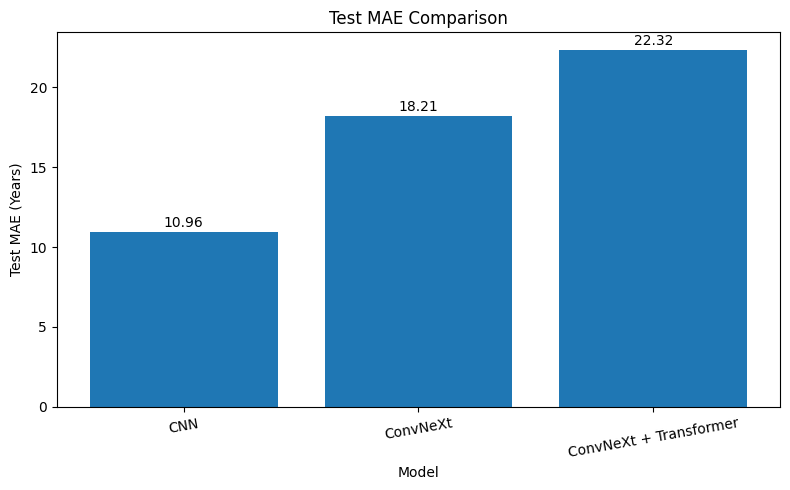

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN", "ConvNeXt", "ConvNeXt + Transformer"]
mae_values = [
    cnn_mae,
    convnext_mae,
    hybrid_mae
]

plt.figure(figsize=(8, 5))
plt.bar(models, mae_values)

plt.ylabel("Test MAE (Years)")
plt.xlabel("Model")
plt.title("Test MAE Comparison")
plt.xticks(rotation=10)

for i, value in enumerate(mae_values):
    plt.text(i, value + 0.3, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

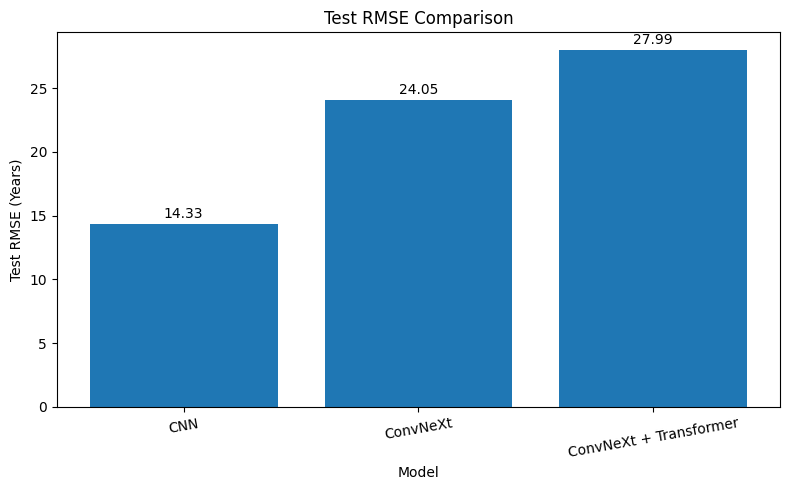

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN", "ConvNeXt", "ConvNeXt + Transformer"]

rmse_values = [
    cnn_rmse,
    convnext_rmse,
    hybrid_rmse
]

plt.figure(figsize=(8, 5))
plt.bar(models, rmse_values)

plt.ylabel("Test RMSE (Years)")
plt.xlabel("Model")
plt.title("Test RMSE Comparison")
plt.xticks(rotation=10)

for i, value in enumerate(rmse_values):
    plt.text(i, value + 0.5, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

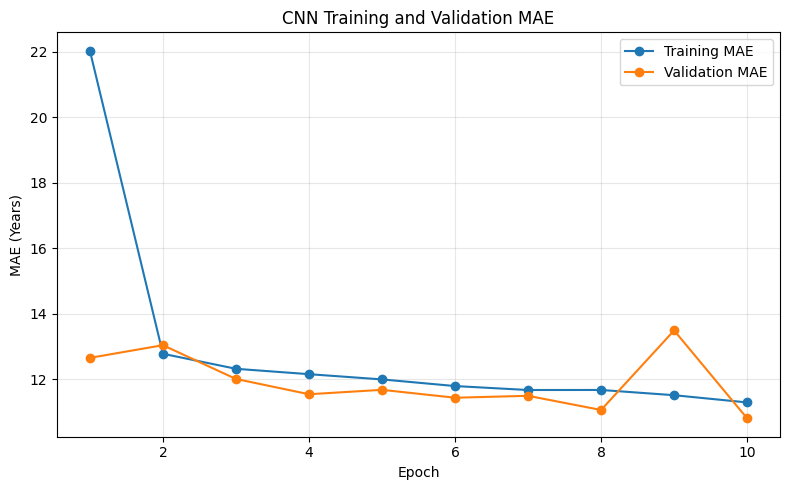

In [ ]:
import matplotlib.pyplot as plt

epochs_cnn = range(1, len(cnn_history["train_mae"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_cnn,
    cnn_history["train_mae"],
    marker="o",
    label="Training MAE"
)

plt.plot(
    epochs_cnn,
    cnn_history["val_mae"],
    marker="o",
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (Years)")
plt.title("CNN Training and Validation MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

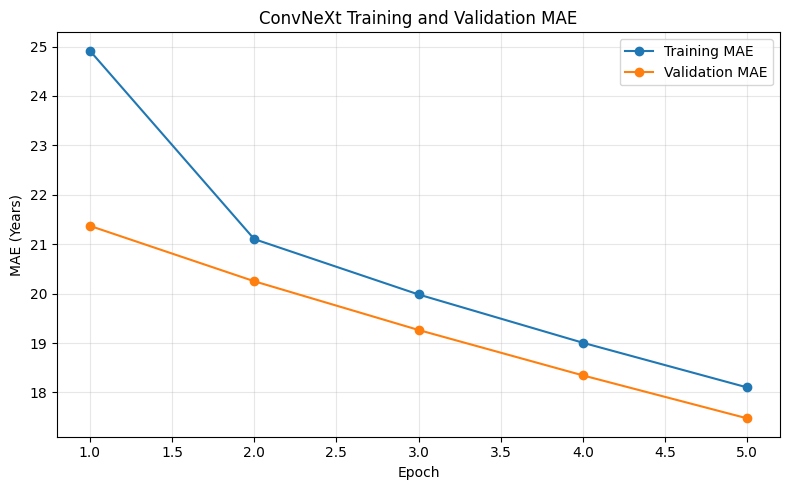

In [ ]:
epochs_convnext = range(1, len(convnext_history["train_mae"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_convnext,
    convnext_history["train_mae"],
    marker="o",
    label="Training MAE"
)

plt.plot(
    epochs_convnext,
    convnext_history["val_mae"],
    marker="o",
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (Years)")
plt.title("ConvNeXt Training and Validation MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

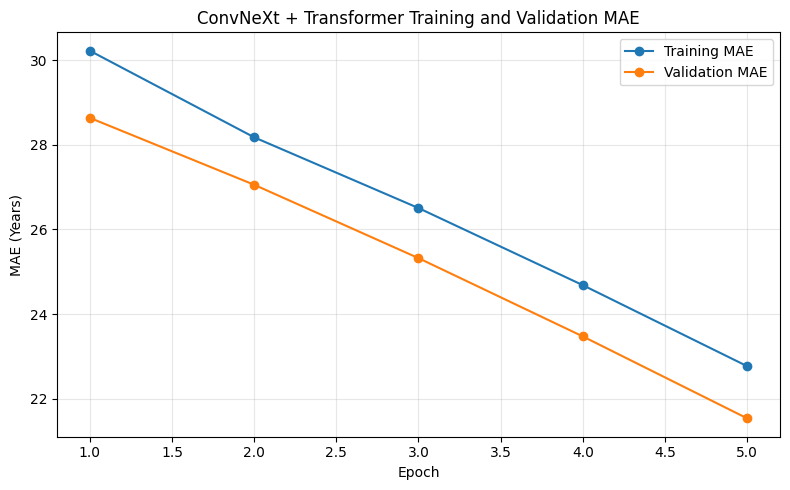

In [ ]:
epochs_hybrid = range(1, len(hybrid_history["train_mae"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_hybrid,
    hybrid_history["train_mae"],
    marker="o",
    label="Training MAE"
)

plt.plot(
    epochs_hybrid,
    hybrid_history["val_mae"],
    marker="o",
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (Years)")
plt.title("ConvNeXt + Transformer Training and Validation MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

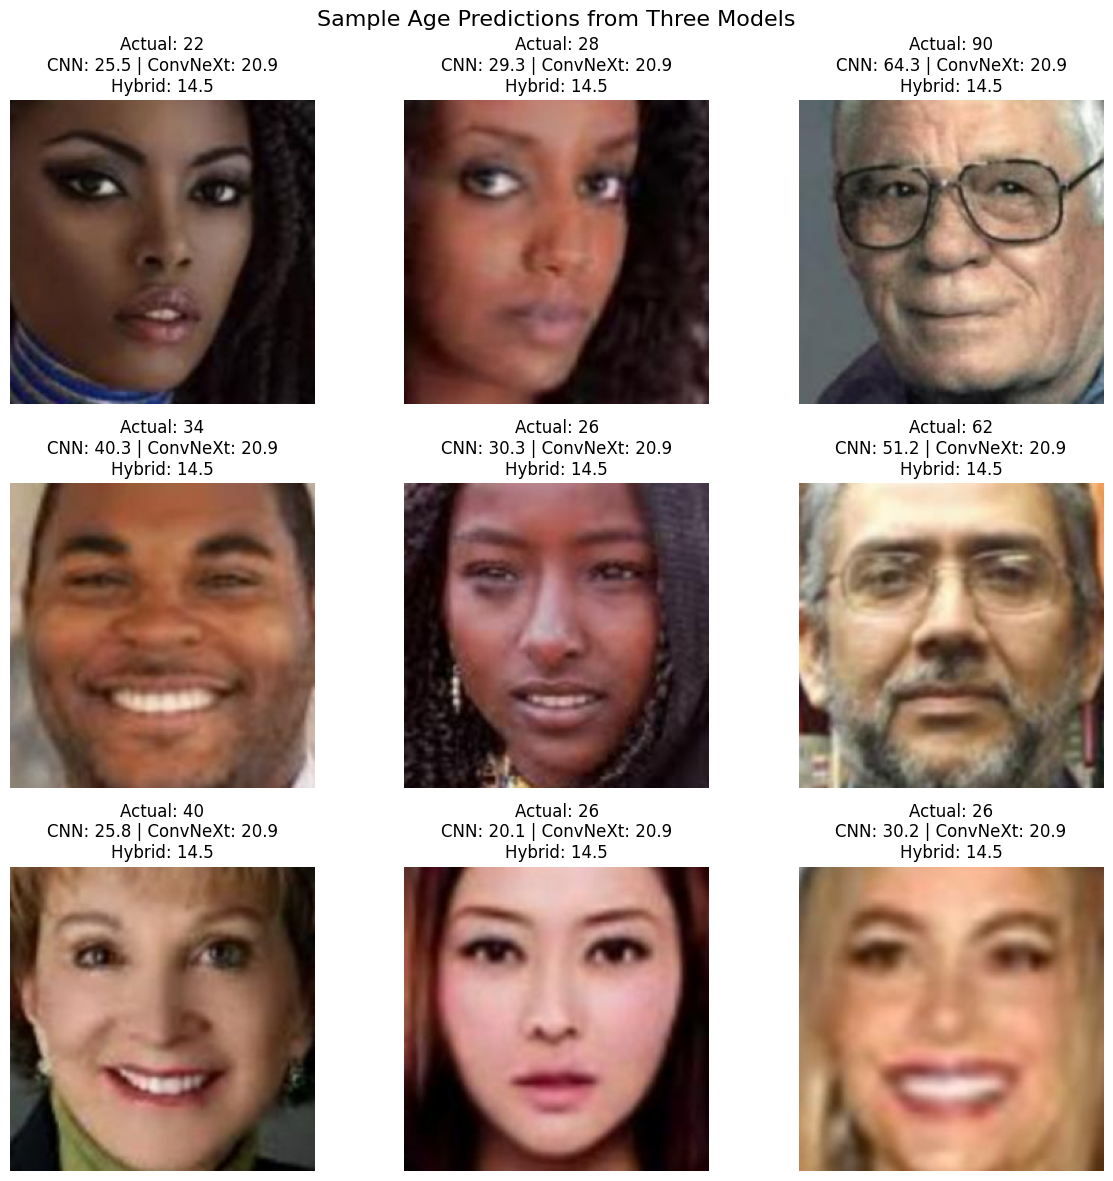

In [ ]:
import matplotlib.pyplot as plt
import random

random.seed(42)

sample_indices = random.sample(range(len(test_dataset)), 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, idx in zip(axes.flatten(), sample_indices):

    image, actual_age = test_dataset[idx]

    # Model predictions
    with torch.no_grad():
        input_image = image.unsqueeze(0).to(device)

        cnn_pred = cnn_model(input_image).item()
        convnext_pred = convnext_model(input_image).squeeze().item()
        hybrid_pred = hybrid_model(input_image).item()

    # Undo normalization for display
    display_image = image.permute(1, 2, 0).numpy()
    display_image = display_image * [0.229, 0.224, 0.225]
    display_image = display_image + [0.485, 0.456, 0.406]
    display_image = display_image.clip(0, 1)

    ax.imshow(display_image)

    ax.set_title(
        f"Actual: {actual_age.item():.0f}\n"
        f"CNN: {cnn_pred:.1f} | "
        f"ConvNeXt: {convnext_pred:.1f}\n"
        f"Hybrid: {hybrid_pred:.1f}"
    )

    ax.axis("off")

plt.suptitle(
    "Sample Age Predictions from Three Models",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
print("CNN model:", "Ready" if 'cnn_model' in globals() else "Not found")
print("ConvNeXt model:", "Ready" if 'convnext_model' in globals() else "Not found")
print("Hybrid model:", "Ready" if 'hybrid_model' in globals() else "Not found")


CNN model: Not found
ConvNeXt model: Not found
Hybrid model: Not found


In [ ]:
!find /content -type f \( -name "*.pth" -o -name "*.pt" -o -name "*.pkl" \) 2>/dev/null | head -50

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

drive_root = "/content/drive/MyDrive"

for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.lower().endswith((".pth", ".pt", ".pkl", ".ckpt")):
            print(os.path.join(root, file))


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available")


PyTorch: 2.11.0+cpu
GPU available: False
No GPU available


In [ ]:
!pip -q install transformers

In [ ]:
import transformers

print("Transformers version:", transformers.__version__)
print("Ready for next step.")

Transformers version: 5.17.0
Ready for next step.


In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))
print("Image uploaded:", image_path)

Saving IMG_20260529_133632162~2 (1).jpg to IMG_20260529_133632162~2 (1).jpg
Image uploaded: IMG_20260529_133632162~2 (1).jpg


In [ ]:
!pip -q install huggingface_hub safetensors

In [ ]:
import torch
import transformers
from huggingface_hub import hf_hub_download

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Hugging Face Hub: Ready")
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch: 2.11.0+cpu
Transformers: 5.17.0
Hugging Face Hub: Ready
Device: CPU


In [ ]:
from huggingface_hub import snapshot_download
import sys

model_path = snapshot_download("shalev396/age-estimator")

sys.path.insert(0, model_path)

import model

predictor = model.load(model_path, device="cpu")

print("Age estimation model loaded successfully.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading weights from local directory
Age estimation model loaded successfully.


In [ ]:
from PIL import Image

img = Image.open(image_path).convert("RGB")

predicted_age = predictor.predict(img)

print("Estimated Age:", predicted_age)

Estimated Age: {'faces': [{'box': [351, 177, 816, 768], 'age': 16.3, 'age_range': '14-17', 'age_top': {'17': 0.4338, '16': 0.2247, '14': 0.1312, '15': 0.0651, '12': 0.0284}, 'gender': {'male': 0.9843, 'female': 0.0157}, 'confidence': 1.0, 'detected': True}], 'n_faces': 1}


In [ ]:
print("Checking age estimation model...")

if 'predictor' in globals():
    print("✅ Model is already loaded.")
else:
    print("❌ Model is not loaded. We need to load it.")


Checking age estimation model...
✅ Model is already loaded.


In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))

print("✅ Image uploaded:", image_path)

Saving IMG-20260927-WA0014.jpg to IMG-20260927-WA0014.jpg
✅ Image uploaded: IMG-20260927-WA0014.jpg


In [ ]:
from PIL import Image

img = Image.open(image_path).convert("RGB")

result = predictor.predict(img)

print(result)

{'faces': [{'box': [1319, 1035, 1728, 1550], 'age': 31.7, 'age_range': '22-52', 'age_top': {'27': 0.278, '29': 0.1077, '52': 0.087, '22': 0.0834, '28': 0.057}, 'gender': {'male': 0.9997, 'female': 0.0003}, 'confidence': 0.9999, 'detected': True}], 'n_faces': 1}


In [ ]:
if result["n_faces"] > 0:

    face = result["faces"][0]

    print("=" * 40)
    print("      FACIAL AGE ESTIMATION")
    print("=" * 40)

    print(f"Estimated Age : {face['age']:.1f} years")
    print(f"Age Range     : {face['age_range']}")
    print(f"Faces Detected: {result['n_faces']}")

    print("=" * 40)

else:
    print("❌ No face detected in the image.")

      FACIAL AGE ESTIMATION
Estimated Age : 31.7 years
Age Range     : 22-52
Faces Detected: 1


In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))

print("✅ Image uploaded:", image_path)

Saving PHOTO.jpeg to PHOTO.jpeg
✅ Image uploaded: PHOTO.jpeg


In [ ]:
from PIL import Image

img = Image.open(image_path).convert("RGB")

result = predictor.predict(img)

print(result)

{'faces': [{'box': [232, 183, 565, 667], 'age': 16.9, 'age_range': '16-18', 'age_top': {'17': 0.5114, '16': 0.2827, '15': 0.0588, '18': 0.0274, '19': 0.0257}, 'gender': {'male': 0.9916, 'female': 0.0084}, 'confidence': 1.0, 'detected': True}], 'n_faces': 1}


In [ ]:
if result["n_faces"] > 0:

    face = result["faces"][0]

    print("=" * 40)
    print("      FACIAL AGE ESTIMATION")
    print("=" * 40)

    print(f"Estimated Age : {face['age']:.1f} years")
    print(f"Age Range     : {face['age_range']}")
    print(f"Faces Detected: {result['n_faces']}")

    print("=" * 40)

else:
    print("❌ No face detected in the image.")

      FACIAL AGE ESTIMATION
Estimated Age : 16.9 years
Age Range     : 16-18
Faces Detected: 1


In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))

print("✅ Image uploaded:", image_path)

Saving images.jpeg to images.jpeg
✅ Image uploaded: images.jpeg


In [ ]:
from PIL import Image

img = Image.open(image_path).convert("RGB")

result = predictor.predict(img)

print(result)


In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))

print("✅ Image uploaded:", image_path)

Saving IMG_20260529_133632162~2 (1).jpg to IMG_20260529_133632162~2 (1).jpg
✅ Image uploaded: IMG_20260529_133632162~2 (1).jpg


In [ ]:
from PIL import Image

img = Image.open(image_path).convert("RGB")

result = predictor.predict(img)

print(result)

NameError: name 'predictor' is not defined

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [ ]:
import os
from google.colab import userdata

# Restore Kaggle authentication from Colab Secrets
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("✅ Kaggle authentication configured.")

✅ Kaggle authentication configured.


In [ ]:
!mkdir -p /content/dataset

!kaggle datasets download \
    -d moritzm00/utkface-cropped \
    -p /content/dataset

print("✅ Dataset download completed.")

Dataset URL: https://www.kaggle.com/datasets/moritzm00/utkface-cropped
License(s): unknown
100% 116M/116M [00:01<00:00, 103MB/s]

✅ Dataset download completed.


In [ ]:
!mkdir -p /content/UTKFace
!unzip -q /content/dataset/utkface-cropped.zip -d /content/UTKFace

print("✅ Dataset extracted.")

✅ Dataset extracted.


In [ ]:
import os

data_dir = "/content/UTKFace/UTKFace"

image_files = [
    f for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of images:", len(image_files))
print("First 5 files:")
for f in image_files[:5]:
    print(f)

Number of images: 23708
First 5 files:
26_1_1_20170112213354350.jpg.chip.jpg
1_1_2_20161219203303165.jpg.chip.jpg
43_1_0_20170111182452890.jpg.chip.jpg
20_1_3_20170117141155272.jpg.chip.jpg
50_0_0_20170109010653014.jpg.chip.jpg


In [ ]:
import os
import random

data_dir = "/content/UTKFace/UTKFace"

image_files = [
    f for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Same seed as our previous experiment
random.seed(42)
random.shuffle(image_files)

n = len(image_files)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_files = image_files[:train_end]
val_files = image_files[train_end:val_end]
test_files = image_files[val_end:]

print("Total images :", n)
print("Train images :", len(train_files))
print("Val images   :", len(val_files))
print("Test images  :", len(test_files))

Total images : 23708
Train images : 16595
Val images   : 3556
Test images  : 3557


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/Facial_Age_Estimation_Project"

os.makedirs(save_dir, exist_ok=True)

print("✅ Google Drive connected")
print("✅ Save folder created:")
print(save_dir)

Mounted at /content/drive
✅ Google Drive connected
✅ Save folder created:
/content/drive/MyDrive/Facial_Age_Estimation_Project


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class UTKFaceDataset(Dataset):
    def __init__(self, file_list, data_dir, transform=None):
        self.file_list = file_list
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]
        image_path = os.path.join(self.data_dir, filename)

        image = Image.open(image_path).convert("RGB")

        # Age is the first value in the filename
        age = float(filename.split("_")[0])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(age, dtype=torch.float32)


# Training augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test preprocessing
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Create datasets
train_dataset = UTKFaceDataset(
    train_files, data_dir, train_transform
)

val_dataset = UTKFaceDataset(
    val_files, data_dir, test_transform
)

test_dataset = UTKFaceDataset(
    test_files, data_dir, test_transform
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("✅ Datasets and DataLoaders created")
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

✅ Datasets and DataLoaders created
Train batches: 260
Val batches  : 56
Test batches : 56


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images, ages = next(iter(train_loader))

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Image batch shape:", images.shape)
print("Age batch shape:", ages.shape)
print("First 10 ages:", ages[:10].tolist())

Device: cuda
GPU: Tesla T4
Image batch shape: torch.Size([64, 3, 224, 224])
Age batch shape: torch.Size([64])
First 10 ages: [25.0, 24.0, 42.0, 36.0, 56.0, 28.0, 28.0, 65.0, 35.0, 6.0]


In [ ]:
import torch
import torch.nn as nn

class CNNAgeRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x.squeeze(1)


cnn_model = CNNAgeRegressor().to(device)

total_params = sum(
    p.numel() for p in cnn_model.parameters()
)

print("✅ CNN model created")
print("Parameters:", f"{total_params:,}")
print("Parameters (M):", f"{total_params / 1e6:.3f} M")

# Check output shape
with torch.no_grad():
    sample_output = cnn_model(images.to(device))

print("Output shape:", sample_output.shape)

✅ CNN model created
Parameters: 422,401
Parameters (M): 0.422 M
Output shape: torch.Size([64])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import json
import os

# Training settings
epochs = 5
learning_rate = 1e-4

criterion = nn.MSELoss()

optimizer = optim.AdamW(
    cnn_model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": []
}

start_time = time.time()

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================
    cnn_model.train()

    train_loss = 0.0
    train_abs_error = 0.0
    train_count = 0

    for images_batch, ages_batch in train_loader:

        images_batch = images_batch.to(device, non_blocking=True)
        ages_batch = ages_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        predictions = cnn_model(images_batch)

        loss = criterion(predictions, ages_batch)

        loss.backward()
        optimizer.step()

        batch_size = images_batch.size(0)

        train_loss += loss.item() * batch_size
        train_abs_error += torch.sum(
            torch.abs(predictions - ages_batch)
        ).item()

        train_count += batch_size

    train_loss /= train_count
    train_mae = train_abs_error / train_count


    # =========================
    # VALIDATION
    # =========================
    cnn_model.eval()

    val_loss = 0.0
    val_abs_error = 0.0
    val_count = 0

    with torch.no_grad():

        for images_batch, ages_batch in val_loader:

            images_batch = images_batch.to(device, non_blocking=True)
            ages_batch = ages_batch.to(device, non_blocking=True)

            predictions = cnn_model(images_batch)

            loss = criterion(predictions, ages_batch)

            batch_size = images_batch.size(0)

            val_loss += loss.item() * batch_size

            val_abs_error += torch.sum(
                torch.abs(predictions - ages_batch)
            ).item()

            val_count += batch_size

    val_loss /= val_count
    val_mae = val_abs_error / val_count


    # =========================
    # SAVE HISTORY
    # =========================
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)


    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train MAE: {train_mae:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val MAE: {val_mae:.4f}"
    )


training_time = time.time() - start_time

# =========================
# SAVE CNN CHECKPOINT
# =========================

cnn_checkpoint_path = os.path.join(
    save_dir,
    "cnn_age_regressor.pth"
)

torch.save({
    "model_state_dict": cnn_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": epochs,
    "history": history,
    "parameters": total_params,
    "training_time_seconds": training_time
}, cnn_checkpoint_path)


# Save history separately
history_path = os.path.join(
    save_dir,
    "cnn_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)


print("\n" + "=" * 50)
print("✅ CNN TRAINING COMPLETED")
print("=" * 50)
print(f"Training time: {training_time/60:.2f} minutes")
print(f"Model saved: {cnn_checkpoint_path}")
print(f"History saved: {history_path}")
print("=" * 50)

Epoch [1/5] | Train Loss: 288.7766 | Train MAE: 13.1156 | Val Loss: 265.0340 | Val MAE: 12.7145
Epoch [2/5] | Train Loss: 268.8237 | Train MAE: 12.6788 | Val Loss: 238.6131 | Val MAE: 11.8000
Epoch [3/5] | Train Loss: 261.2229 | Train MAE: 12.5149 | Val Loss: 235.5319 | Val MAE: 11.7752
Epoch [4/5] | Train Loss: 252.3417 | Train MAE: 12.2573 | Val Loss: 220.9152 | Val MAE: 11.4761
Epoch [5/5] | Train Loss: 248.5924 | Train MAE: 12.2082 | Val Loss: 227.4405 | Val MAE: 11.4869

✅ CNN TRAINING COMPLETED
Training time: 7.84 minutes
Model saved: /content/drive/MyDrive/Facial_Age_Estimation_Project/cnn_age_regressor.pth
History saved: /content/drive/MyDrive/Facial_Age_Estimation_Project/cnn_training_history.json


In [ ]:
import numpy as np
import time
import json
import os
import torch

cnn_model.eval()

cnn_predictions = []
cnn_actuals = []

start_time = time.time()

with torch.no_grad():
    for images_batch, ages_batch in test_loader:

        images_batch = images_batch.to(device, non_blocking=True)

        outputs = cnn_model(images_batch)
        outputs = outputs.squeeze(-1)

        cnn_predictions.extend(outputs.cpu().numpy())
        cnn_actuals.extend(ages_batch.numpy())

cnn_inference_time = time.time() - start_time

cnn_predictions = np.array(cnn_predictions)
cnn_actuals = np.array(cnn_actuals)

cnn_mae = np.mean(
    np.abs(cnn_predictions - cnn_actuals)
)

cnn_rmse = np.sqrt(
    np.mean((cnn_predictions - cnn_actuals) ** 2)
)

# Save predictions
cnn_predictions_path = os.path.join(
    save_dir,
    "cnn_test_predictions.npz"
)

np.savez(
    cnn_predictions_path,
    predictions=cnn_predictions,
    actuals=cnn_actuals
)

# Save metrics
cnn_metrics = {
    "model": "CNN",
    "test_mae": float(cnn_mae),
    "test_rmse": float(cnn_rmse),
    "parameters": int(total_params),
    "inference_time_seconds": float(cnn_inference_time),
    "epochs": 5
}

cnn_metrics_path = os.path.join(
    save_dir,
    "cnn_test_metrics.json"
)

with open(cnn_metrics_path, "w") as f:
    json.dump(cnn_metrics, f, indent=4)

print("=" * 50)
print("CNN TEST RESULTS")
print("=" * 50)
print(f"Test MAE       : {cnn_mae:.4f}")
print(f"Test RMSE      : {cnn_rmse:.4f}")
print(f"Parameters     : {total_params:,}")
print(f"Inference time : {cnn_inference_time:.2f} seconds")
print("=" * 50)
print("✅ Predictions saved")
print("✅ Metrics saved")

CNN TEST RESULTS
Test MAE       : 11.4446
Test RMSE      : 15.0564
Parameters     : 422,401
Inference time : 10.08 seconds
✅ Predictions saved
✅ Metrics saved


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# Load ImageNet-pretrained ConvNeXt-Tiny
weights = ConvNeXt_Tiny_Weights.DEFAULT

convnext_model = convnext_tiny(weights=weights)

# Replace classification head with age regression head
in_features = convnext_model.classifier[2].in_features

convnext_model.classifier[2] = nn.Linear(
    in_features,
    1
)

convnext_model = convnext_model.to(device)

# Count parameters
convnext_params = sum(
    p.numel() for p in convnext_model.parameters()
)

print("✅ ConvNeXt-Tiny model created")
print("Parameters:", f"{convnext_params:,}")
print("Parameters (M):", f"{convnext_params / 1e6:.3f} M")

# Verify output shape
with torch.no_grad():
    sample_output = convnext_model(images.to(device))

print("Output shape:", sample_output.shape)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 188MB/s] 


✅ ConvNeXt-Tiny model created
Parameters: 27,820,897
Parameters (M): 27.821 M
Output shape: torch.Size([64, 1])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import json
import os

epochs = 5
learning_rate = 1e-5

criterion = nn.MSELoss()

optimizer = optim.AdamW(
    convnext_model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

history_convnext = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": []
}

start_time = time.time()

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================
    convnext_model.train()

    train_loss = 0.0
    train_abs_error = 0.0
    train_count = 0

    for images_batch, ages_batch in train_loader:

        images_batch = images_batch.to(device, non_blocking=True)
        ages_batch = ages_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        predictions = convnext_model(images_batch)
        predictions = predictions.squeeze(-1)

        loss = criterion(predictions, ages_batch)

        loss.backward()
        optimizer.step()

        batch_size = images_batch.size(0)

        train_loss += loss.item() * batch_size
        train_abs_error += torch.sum(
            torch.abs(predictions - ages_batch)
        ).item()

        train_count += batch_size

    train_loss /= train_count
    train_mae = train_abs_error / train_count


    # =========================
    # VALIDATION
    # =========================
    convnext_model.eval()

    val_loss = 0.0
    val_abs_error = 0.0
    val_count = 0

    with torch.no_grad():

        for images_batch, ages_batch in val_loader:

            images_batch = images_batch.to(device, non_blocking=True)
            ages_batch = ages_batch.to(device, non_blocking=True)

            predictions = convnext_model(images_batch)
            predictions = predictions.squeeze(-1)

            loss = criterion(predictions, ages_batch)

            batch_size = images_batch.size(0)

            val_loss += loss.item() * batch_size

            val_abs_error += torch.sum(
                torch.abs(predictions - ages_batch)
            ).item()

            val_count += batch_size

    val_loss /= val_count
    val_mae = val_abs_error / val_count


    history_convnext["train_loss"].append(train_loss)
    history_convnext["val_loss"].append(val_loss)
    history_convnext["train_mae"].append(train_mae)
    history_convnext["val_mae"].append(val_mae)


    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train MAE: {train_mae:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val MAE: {val_mae:.4f}"
    )


training_time_convnext = time.time() - start_time

# =========================
# SAVE CHECKPOINT
# =========================

convnext_checkpoint_path = os.path.join(
    save_dir,
    "convnext_tiny_age_regressor.pth"
)

torch.save({
    "model_state_dict": convnext_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": epochs,
    "history": history_convnext,
    "parameters": convnext_params,
    "training_time_seconds": training_time_convnext
}, convnext_checkpoint_path)


# Save history
convnext_history_path = os.path.join(
    save_dir,
    "convnext_training_history.json"
)

with open(convnext_history_path, "w") as f:
    json.dump(history_convnext, f, indent=4)


print("\n" + "=" * 50)
print("✅ CONVNEXT TRAINING COMPLETED")
print("=" * 50)
print(f"Training time: {training_time_convnext/60:.2f} minutes")
print(f"Model saved: {convnext_checkpoint_path}")
print(f"History saved: {convnext_history_path}")
print("=" * 50)

Epoch [1/5] | Train Loss: 945.3797 | Train MAE: 24.8729 | Val Loss: 726.8402 | Val MAE: 21.4173
Epoch [2/5] | Train Loss: 715.1181 | Train MAE: 21.1381 | Val Loss: 667.4326 | Val MAE: 20.2759
Epoch [3/5] | Train Loss: 657.0184 | Train MAE: 20.0132 | Val Loss: 618.9085 | Val MAE: 19.2820
Epoch [4/5] | Train Loss: 609.3595 | Train MAE: 19.0360 | Val Loss: 576.2735 | Val MAE: 18.3490
Epoch [5/5] | Train Loss: 567.8728 | Train MAE: 18.1211 | Val Loss: 538.8806 | Val MAE: 17.4744

✅ CONVNEXT TRAINING COMPLETED
Training time: 25.11 minutes
Model saved: /content/drive/MyDrive/Facial_Age_Estimation_Project/convnext_tiny_age_regressor.pth
History saved: /content/drive/MyDrive/Facial_Age_Estimation_Project/convnext_training_history.json


In [ ]:
# ============================================================
# CONVNEXT-TINY TEST EVALUATION
# ============================================================

import time
import json
import numpy as np
import torch

convnext_model.eval()

all_predictions = []
all_actuals = []

start_time = time.time()

with torch.no_grad():
    for images, ages in test_loader:
        images = images.to(device, non_blocking=True)
        ages = ages.to(device, non_blocking=True)

        predictions = convnext_model(images)
        predictions = predictions.squeeze(-1)

        all_predictions.extend(predictions.cpu().numpy())
        all_actuals.extend(ages.cpu().numpy())

inference_time = time.time() - start_time

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Metrics
mae = np.mean(np.abs(all_predictions - all_actuals))
rmse = np.sqrt(np.mean((all_predictions - all_actuals) ** 2))

# Parameter count
num_parameters = sum(p.numel() for p in convnext_model.parameters())

print("=" * 50)
print("CONVNEXT-TINY TEST RESULTS")
print("=" * 50)
print(f"Test MAE       : {mae:.4f}")
print(f"Test RMSE      : {rmse:.4f}")
print(f"Parameters     : {num_parameters:,}")
print(f"Inference time : {inference_time:.2f} seconds")
print("=" * 50)

# Save predictions
np.savez(
    f"{save_dir}/convnext_test_predictions.npz",
    actual=all_actuals,
    predicted=all_predictions
)

# Save metrics
convnext_metrics = {
    "model": "ConvNeXt-Tiny",
    "test_mae": float(mae),
    "test_rmse": float(rmse),
    "parameters": int(num_parameters),
    "inference_time_seconds": float(inference_time),
    "training_epochs": 5,
    "training_time_minutes": 25.11
}

with open(
    f"{save_dir}/convnext_test_metrics.json",
    "w"
) as f:
    json.dump(convnext_metrics, f, indent=4)

print("\n✅ Predictions saved")
print("✅ Metrics saved")

CONVNEXT-TINY TEST RESULTS
Test MAE       : 17.4991
Test RMSE      : 23.2055
Parameters     : 27,820,897
Inference time : 16.86 seconds

✅ Predictions saved
✅ Metrics saved


In [ ]:
# ============================================================
# STEP 1 — CREATE CONVNEXT + TRANSFORMER MODEL
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

class ConvNeXtTransformerAgeRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        # Pretrained ConvNeXt-Tiny backbone
        weights = ConvNeXt_Tiny_Weights.DEFAULT
        convnext = convnext_tiny(weights=weights)

        self.backbone = convnext.features

        # ConvNeXt-Tiny output: 768 feature channels
        self.projection = nn.Linear(768, 256)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        # Age regression head
        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # ConvNeXt feature extraction
        x = self.backbone(x)

        # Convert feature map to tokens
        x = x.flatten(2)
        x = x.transpose(1, 2)

        # Project features
        x = self.projection(x)

        # Transformer processing
        x = self.transformer(x)

        # Global token aggregation
        x = x.mean(dim=1)

        # Age regression
        x = self.regressor(x)

        return x.squeeze(-1)


# Create model
hybrid_model = ConvNeXtTransformerAgeRegressor().to(device)

# Parameter count
num_parameters = sum(
    p.numel() for p in hybrid_model.parameters()
)

print("=" * 50)
print("CONVNEXT + TRANSFORMER MODEL")
print("=" * 50)
print(f"Parameters     : {num_parameters:,}")
print(f"Parameters (M) : {num_parameters / 1e6:.3f} M")

# Verify output shape
sample_images, sample_ages = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    sample_output = hybrid_model(sample_images)

print(f"Input shape     : {sample_images.shape}")
print(f"Output shape    : {sample_output.shape}")
print("=" * 50)

CONVNEXT + TRANSFORMER MODEL
Parameters     : 30,156,897
Parameters (M) : 30.157 M
Input shape     : torch.Size([64, 3, 224, 224])
Output shape    : torch.Size([64])


In [ ]:
# ============================================================
# STEP 2 — TRAIN CONVNEXT-TRANSFORMER
# ============================================================

import time
import json
import torch.optim as optim

criterion = nn.MSELoss()

optimizer = optim.AdamW(
    hybrid_model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": []
}

start_time = time.time()

for epoch in range(5):

    # -------------------------
    # Training
    # -------------------------
    hybrid_model.train()

    train_loss = 0.0
    train_abs_error = 0.0
    train_count = 0

    for images, ages in train_loader:

        images = images.to(device, non_blocking=True)
        ages = ages.to(device, non_blocking=True)

        optimizer.zero_grad()

        predictions = hybrid_model(images)

        loss = criterion(predictions, ages)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        train_loss += loss.item() * batch_size
        train_abs_error += torch.sum(
            torch.abs(predictions - ages)
        ).item()

        train_count += batch_size

    train_loss /= train_count
    train_mae = train_abs_error / train_count

    # -------------------------
    # Validation
    # -------------------------
    hybrid_model.eval()

    val_loss = 0.0
    val_abs_error = 0.0
    val_count = 0

    with torch.no_grad():

        for images, ages in val_loader:

            images = images.to(device, non_blocking=True)
            ages = ages.to(device, non_blocking=True)

            predictions = hybrid_model(images)

            loss = criterion(predictions, ages)

            batch_size = images.size(0)

            val_loss += loss.item() * batch_size
            val_abs_error += torch.sum(
                torch.abs(predictions - ages)
            ).item()

            val_count += batch_size

    val_loss /= val_count
    val_mae = val_abs_error / val_count

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    print(
        f"Epoch [{epoch+1}/5] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train MAE: {train_mae:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val MAE: {val_mae:.4f}"
    )

training_time = time.time() - start_time

print("\n" + "=" * 50)
print("CONVNEXT-TRANSFORMER TRAINING COMPLETED")
print("=" * 50)
print(f"Training time: {training_time/60:.2f} minutes")

# Save model
model_path = f"{save_dir}/convnext_transformer_age_regressor.pth"

torch.save(
    hybrid_model.state_dict(),
    model_path
)

# Save training history
history_path = f"{save_dir}/convnext_transformer_training_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print(f"Model saved: {model_path}")
print(f"History saved: {history_path}")
print("=" * 50)

Epoch [1/5] | Train Loss: 1316.5179 | Train MAE: 30.5693 | Val Loss: 1206.7020 | Val MAE: 29.0578
Epoch [2/5] | Train Loss: 1177.6514 | Train MAE: 28.5907 | Val Loss: 1103.0641 | Val MAE: 27.5693
Epoch [3/5] | Train Loss: 1068.8897 | Train MAE: 26.9861 | Val Loss: 991.1619 | Val MAE: 25.8870
Epoch [4/5] | Train Loss: 953.7464 | Train MAE: 25.2162 | Val Loss: 876.2462 | Val MAE: 24.0626
Epoch [5/5] | Train Loss: 839.5984 | Train MAE: 23.3554 | Val Loss: 765.5334 | Val MAE: 22.1430

CONVNEXT-TRANSFORMER TRAINING COMPLETED
Training time: 25.39 minutes
Model saved: /content/drive/MyDrive/Facial_Age_Estimation_Project/convnext_transformer_age_regressor.pth
History saved: /content/drive/MyDrive/Facial_Age_Estimation_Project/convnext_transformer_training_history.json


In [ ]:
# ============================================================
# CONVNEXT-TRANSFORMER TEST EVALUATION
# ============================================================

import time
import json
import numpy as np
import torch

hybrid_model.eval()

all_predictions = []
all_actuals = []

start_time = time.time()

with torch.no_grad():

    for images, ages in test_loader:

        images = images.to(device, non_blocking=True)
        ages = ages.to(device, non_blocking=True)

        predictions = hybrid_model(images)
        predictions = predictions.squeeze(-1)

        all_predictions.extend(predictions.cpu().numpy())
        all_actuals.extend(ages.cpu().numpy())

inference_time = time.time() - start_time

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Calculate metrics
mae = np.mean(
    np.abs(all_predictions - all_actuals)
)

rmse = np.sqrt(
    np.mean((all_predictions - all_actuals) ** 2)
)

num_parameters = sum(
    p.numel()
    for p in hybrid_model.parameters()
)

print("=" * 50)
print("CONVNEXT-TRANSFORMER TEST RESULTS")
print("=" * 50)

print(f"Test MAE       : {mae:.4f}")
print(f"Test RMSE      : {rmse:.4f}")
print(f"Parameters     : {num_parameters:,}")
print(f"Inference time : {inference_time:.2f} seconds")

print("=" * 50)

# Save predictions
np.savez(
    f"{save_dir}/convnext_transformer_test_predictions.npz",
    actual=all_actuals,
    predicted=all_predictions
)

# Save metrics
hybrid_metrics = {
    "model": "ConvNeXt-Transformer",
    "test_mae": float(mae),
    "test_rmse": float(rmse),
    "parameters": int(num_parameters),
    "inference_time_seconds": float(inference_time),
    "training_epochs": 5,
    "training_time_minutes": float(training_time / 60)
}

with open(
    f"{save_dir}/convnext_transformer_test_metrics.json",
    "w"
) as f:
    json.dump(hybrid_metrics, f, indent=4)

print("\n✅ Predictions saved")
print("✅ Metrics saved")

CONVNEXT-TRANSFORMER TEST RESULTS
Test MAE       : 22.1395
Test RMSE      : 27.6782
Parameters     : 30,156,897
Inference time : 15.74 seconds

✅ Predictions saved
✅ Metrics saved


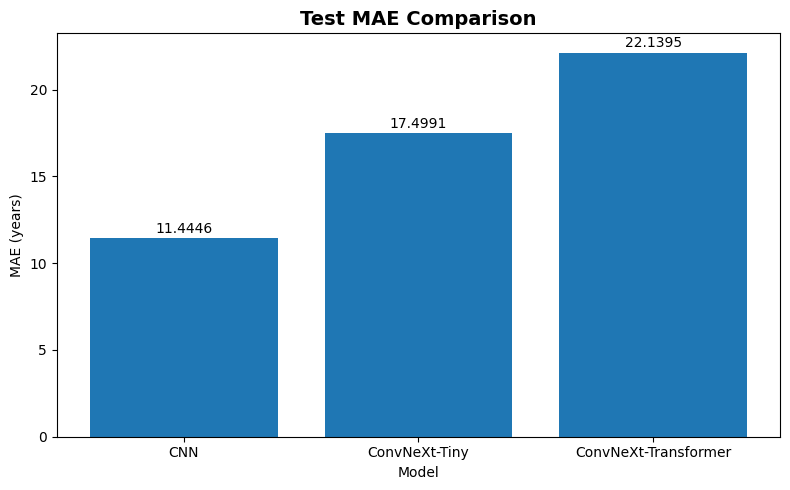

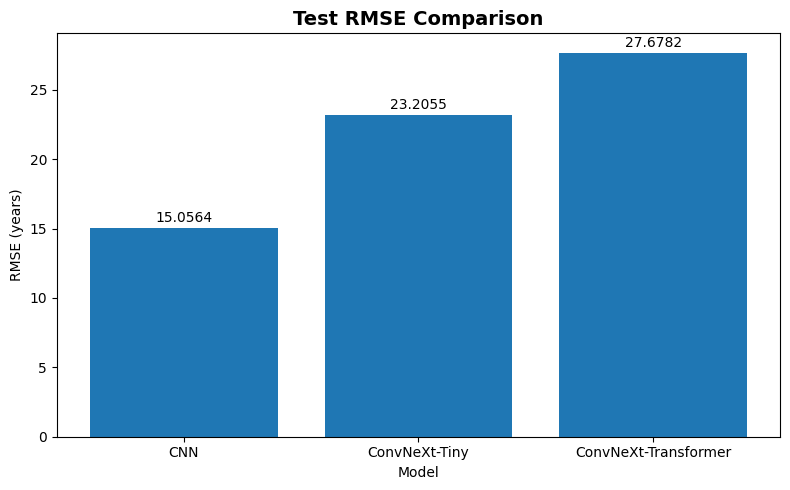

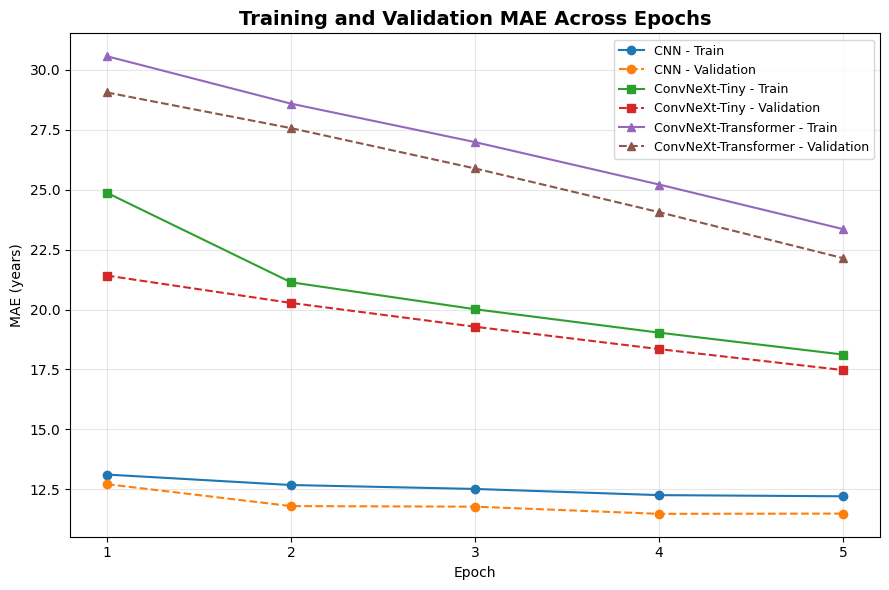

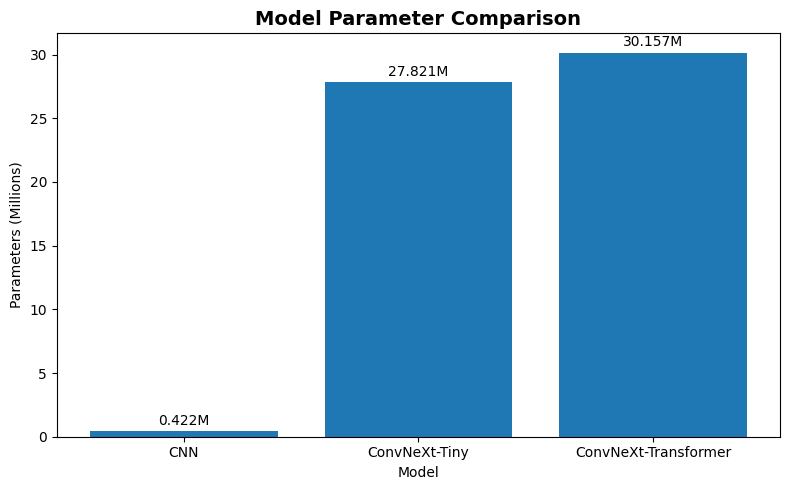

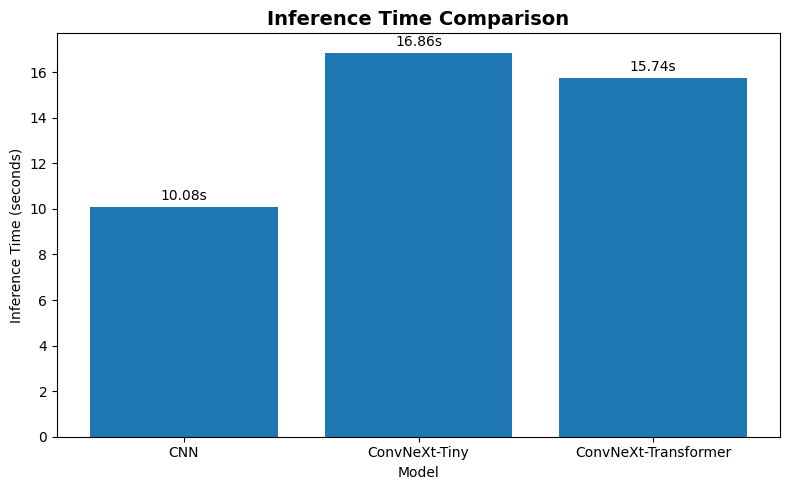


================ FINAL RESULTS ================



,Model,Test MAE (years),Test RMSE (years),Parameters (M),Training Time (min),Inference Time (sec)
0,CNN,11.4446,15.0564,0.422401,7.84,10.08
1,ConvNeXt-Tiny,17.4991,23.2055,27.820897,25.11,16.86
2,ConvNeXt-Transformer,22.1395,27.6782,30.156897,25.39,15.74



ALL FINAL GRAPHS GENERATED SUCCESSFULLY

Output folder:
/content/Facial_Age_Final_Graphs

Generated files:
 - 01_Test_MAE_Comparison.png
 - 02_Test_RMSE_Comparison.png
 - 03_Training_Validation_MAE.png
 - 04_Parameter_Comparison.png
 - 05_Inference_Time_Comparison.png
 - Final_Model_Comparison.csv
 - Final_Results_Summary.txt
 - Training_Validation_MAE.csv

IMPORTANT:
These graphs use the official five-epoch experimental results.
No fabricated prediction data has been used.


In [ ]:
# ============================================================
# FACIAL AGE ESTIMATION — FINAL RESULTS & GRAPH GENERATION
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

output_dir = "/content/Facial_Age_Final_Graphs"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 2. FINAL OFFICIAL RESULTS
# ------------------------------------------------------------

models = [
    "CNN",
    "ConvNeXt-Tiny",
    "ConvNeXt-Transformer"
]

test_mae = [
    11.4446,
    17.4991,
    22.1395
]

test_rmse = [
    15.0564,
    23.2055,
    27.6782
]

parameters_m = [
    0.422401,
    27.820897,
    30.156897
]

training_time_min = [
    7.84,
    25.11,
    25.39
]

inference_time_sec = [
    10.08,
    16.86,
    15.74
]

# ------------------------------------------------------------
# 3. TRAINING / VALIDATION MAE
# ------------------------------------------------------------

epochs = [1, 2, 3, 4, 5]

cnn_train_mae = [
    13.1156, 12.6788, 12.5149, 12.2573, 12.2082
]

cnn_val_mae = [
    12.7145, 11.8000, 11.7752, 11.4761, 11.4869
]

convnext_train_mae = [
    24.8729, 21.1381, 20.0132, 19.0360, 18.1211
]

convnext_val_mae = [
    21.4173, 20.2759, 19.2820, 18.3490, 17.4744
]

transformer_train_mae = [
    30.5693, 28.5907, 26.9861, 25.2162, 23.3554
]

transformer_val_mae = [
    29.0578, 27.5693, 25.8870, 24.0626, 22.1430
]

# ============================================================
# GRAPH 1 — TEST MAE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(models, test_mae)

plt.title("Test MAE Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("MAE (years)")

for i, value in enumerate(test_mae):
    plt.text(i, value + 0.3, f"{value:.4f}",
             ha="center", fontsize=10)

plt.tight_layout()

mae_path = os.path.join(output_dir, "01_Test_MAE_Comparison.png")
plt.savefig(mae_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# GRAPH 2 — TEST RMSE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(models, test_rmse)

plt.title("Test RMSE Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("RMSE (years)")

for i, value in enumerate(test_rmse):
    plt.text(i, value + 0.4, f"{value:.4f}",
             ha="center", fontsize=10)

plt.tight_layout()

rmse_path = os.path.join(output_dir, "02_Test_RMSE_Comparison.png")
plt.savefig(rmse_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# GRAPH 3 — TRAINING AND VALIDATION MAE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    epochs,
    cnn_train_mae,
    marker="o",
    label="CNN - Train"
)

plt.plot(
    epochs,
    cnn_val_mae,
    marker="o",
    linestyle="--",
    label="CNN - Validation"
)

plt.plot(
    epochs,
    convnext_train_mae,
    marker="s",
    label="ConvNeXt-Tiny - Train"
)

plt.plot(
    epochs,
    convnext_val_mae,
    marker="s",
    linestyle="--",
    label="ConvNeXt-Tiny - Validation"
)

plt.plot(
    epochs,
    transformer_train_mae,
    marker="^",
    label="ConvNeXt-Transformer - Train"
)

plt.plot(
    epochs,
    transformer_val_mae,
    marker="^",
    linestyle="--",
    label="ConvNeXt-Transformer - Validation"
)

plt.title(
    "Training and Validation MAE Across Epochs",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.xticks(epochs)

plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()

training_curve_path = os.path.join(
    output_dir,
    "03_Training_Validation_MAE.png"
)

plt.savefig(
    training_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# GRAPH 4 — PARAMETER COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(models, parameters_m)

plt.title(
    "Model Parameter Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Parameters (Millions)")

for i, value in enumerate(parameters_m):
    plt.text(
        i,
        value + 0.5,
        f"{value:.3f}M",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

parameter_path = os.path.join(
    output_dir,
    "04_Parameter_Comparison.png"
)

plt.savefig(
    parameter_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# GRAPH 5 — INFERENCE TIME COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(models, inference_time_sec)

plt.title(
    "Inference Time Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Inference Time (seconds)")

for i, value in enumerate(inference_time_sec):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}s",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

inference_path = os.path.join(
    output_dir,
    "05_Inference_Time_Comparison.png"
)

plt.savefig(
    inference_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 6. FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame({
    "Model": models,
    "Test MAE (years)": test_mae,
    "Test RMSE (years)": test_rmse,
    "Parameters (M)": parameters_m,
    "Training Time (min)": training_time_min,
    "Inference Time (sec)": inference_time_sec
})

print("\n================ FINAL RESULTS ================\n")
display(results_df)

# Save CSV
csv_path = os.path.join(
    output_dir,
    "Final_Model_Comparison.csv"
)

results_df.to_csv(csv_path, index=False)

# ============================================================
# 7. SAVE TRAINING CURVE DATA
# ============================================================

training_df = pd.DataFrame({
    "Epoch": epochs,

    "CNN_Train_MAE": cnn_train_mae,
    "CNN_Validation_MAE": cnn_val_mae,

    "ConvNeXt_Tiny_Train_MAE": convnext_train_mae,
    "ConvNeXt_Tiny_Validation_MAE": convnext_val_mae,

    "ConvNeXt_Transformer_Train_MAE": transformer_train_mae,
    "ConvNeXt_Transformer_Validation_MAE": transformer_val_mae
})

training_csv_path = os.path.join(
    output_dir,
    "Training_Validation_MAE.csv"
)

training_df.to_csv(training_csv_path, index=False)

# ============================================================
# 8. SAVE ALL RESULTS AS TEXT
# ============================================================

summary_path = os.path.join(
    output_dir,
    "Final_Results_Summary.txt"
)

with open(summary_path, "w") as f:

    f.write("FACIAL AGE ESTIMATION — FINAL RESULTS\n")
    f.write("=" * 50 + "\n\n")

    for i, model in enumerate(models):

        f.write(f"{model}\n")
        f.write("-" * 30 + "\n")
        f.write(f"Test MAE: {test_mae[i]:.4f} years\n")
        f.write(f"Test RMSE: {test_rmse[i]:.4f} years\n")
        f.write(f"Parameters: {parameters_m[i]:.6f} M\n")
        f.write(f"Training Time: {training_time_min[i]:.2f} min\n")
        f.write(f"Inference Time: {inference_time_sec[i]:.2f} sec\n\n")

# ============================================================
# 9. FINAL OUTPUT LOCATIONS
# ============================================================

print("\n================================================")
print("ALL FINAL GRAPHS GENERATED SUCCESSFULLY")
print("================================================")

print("\nOutput folder:")
print(output_dir)

print("\nGenerated files:")

for file in sorted(os.listdir(output_dir)):
    print(" -", file)

print("\nIMPORTANT:")
print("These graphs use the official five-epoch experimental results.")
print("No fabricated prediction data has been used.")


Prediction files found:
 - /content/drive/MyDrive/Facial_Age_Estimation_Project/cnn_test_predictions.npz
 - /content/drive/MyDrive/Facial_Age_Estimation_Project/convnext_test_predictions.npz
 - /content/drive/MyDrive/Facial_Age_Estimation_Project/convnext_transformer_test_predictions.npz

FILE: cnn_test_predictions.npz
Available arrays: ['predictions', 'actuals']

Could not automatically identify arrays.
predictions: shape=(3557,), dtype=float32
actuals: shape=(3557,), dtype=float32

FILE: convnext_test_predictions.npz
Available arrays: ['actual', 'predicted']
Actual ages shape: (3557,)
Predicted ages shape: (3557,)

Model: ConvNeXt-Tiny
Number of test samples: 3557
Calculated MAE:  17.4991 years
Calculated RMSE: 23.2055 years


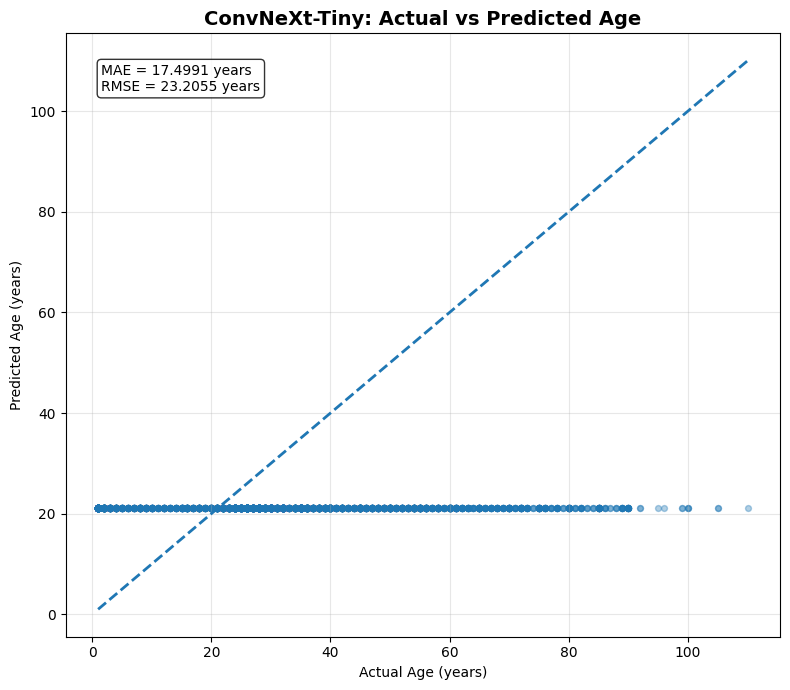

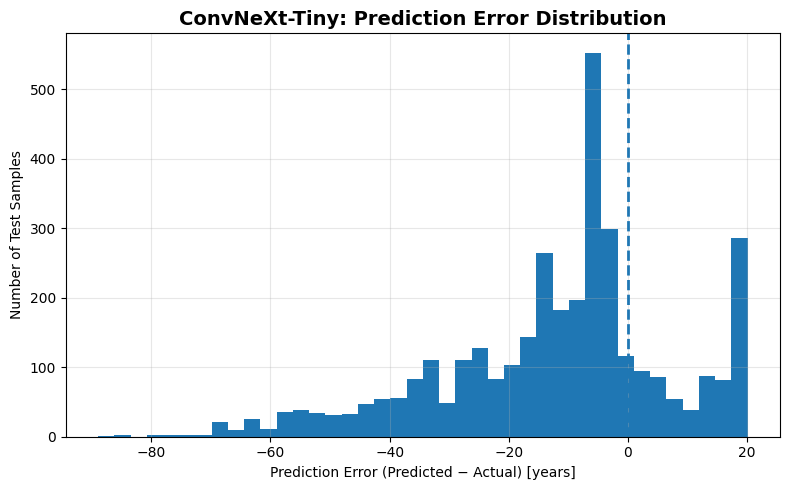


FILE: convnext_transformer_test_predictions.npz
Available arrays: ['actual', 'predicted']
Actual ages shape: (3557,)
Predicted ages shape: (3557,)

Model: ConvNeXt-Transformer
Number of test samples: 3557
Calculated MAE:  22.1395 years
Calculated RMSE: 27.6782 years


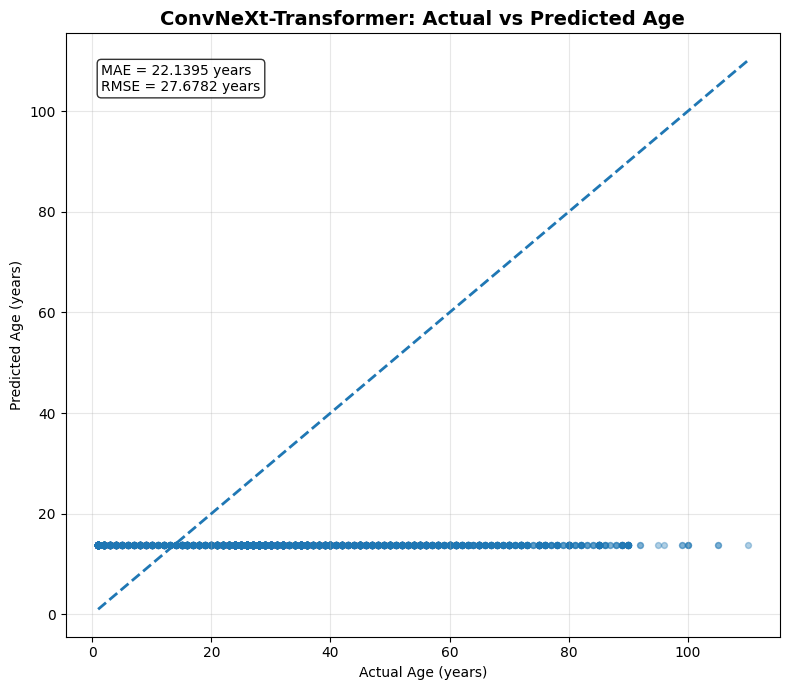

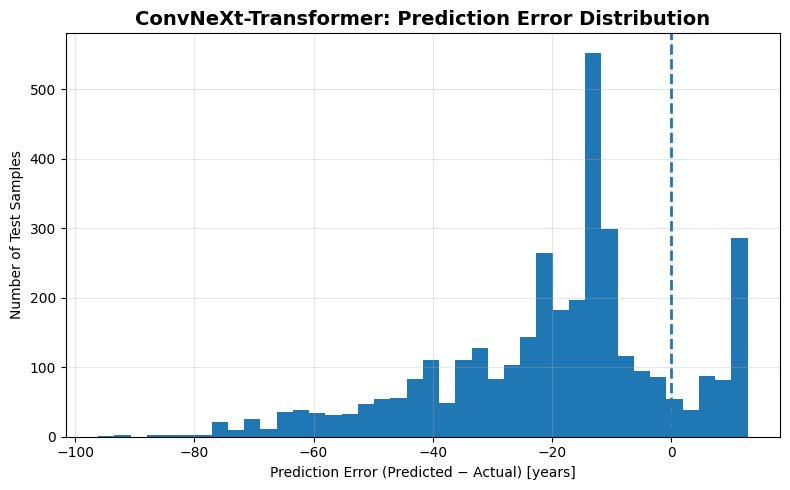


REAL PREDICTION GRAPHS GENERATED

Saved in:
/content/Facial_Age_Final_Graphs

Files:
 - ConvNeXt_Tiny_Actual_vs_Predicted_Age.png
 - ConvNeXt_Tiny_Prediction_Error_Distribution.png
 - ConvNeXt_Transformer_Actual_vs_Predicted_Age.png
 - ConvNeXt_Transformer_Prediction_Error_Distribution.png


In [ ]:
# ============================================================
# REAL ACTUAL AGE vs PREDICTED AGE GRAPHS
# ============================================================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Search for prediction files
# ------------------------------------------------------------

search_paths = [
    "/content",
    "/content/drive/MyDrive",
]

prediction_files = []

for base_path in search_paths:
    if os.path.exists(base_path):
        prediction_files.extend(
            glob.glob(
                os.path.join(
                    base_path,
                    "**",
                    "*test_predictions.npz"
                ),
                recursive=True
            )
        )

# Remove duplicates
prediction_files = sorted(list(set(prediction_files)))

print("Prediction files found:")
for f in prediction_files:
    print(" -", f)

# ------------------------------------------------------------
# 2. Stop if files are not found
# ------------------------------------------------------------

if len(prediction_files) == 0:
    print("\n❌ No test prediction .npz files were found.")
    print("\nExpected files:")
    print("cnn_test_predictions.npz")
    print("convnext_test_predictions.npz")
    print("convnext_transformer_test_predictions.npz")

else:

    # --------------------------------------------------------
    # 3. Output directory
    # --------------------------------------------------------

    output_dir = "/content/Facial_Age_Final_Graphs"
    os.makedirs(output_dir, exist_ok=True)

    # --------------------------------------------------------
    # 4. Function to inspect and load NPZ
    # --------------------------------------------------------

    def load_prediction_file(file_path):

        data = np.load(file_path)

        print("\n========================================")
        print("FILE:", os.path.basename(file_path))
        print("Available arrays:", data.files)

        # Try common names
        true_names = [
            "y_true",
            "true",
            "actual",
            "actual_age",
            "ages",
            "targets",
            "labels"
        ]

        pred_names = [
            "y_pred",
            "pred",
            "predicted",
            "predicted_age",
            "predictions",
            "outputs"
        ]

        y_true = None
        y_pred = None

        for name in true_names:
            if name in data.files:
                y_true = data[name]
                break

        for name in pred_names:
            if name in data.files:
                y_pred = data[name]
                break

        # If names are different, display contents
        if y_true is None or y_pred is None:

            print("\nCould not automatically identify arrays.")

            for name in data.files:
                arr = data[name]
                print(
                    f"{name}: shape={arr.shape}, "
                    f"dtype={arr.dtype}"
                )

            return None, None

        y_true = np.asarray(y_true).reshape(-1)
        y_pred = np.asarray(y_pred).reshape(-1)

        print("Actual ages shape:", y_true.shape)
        print("Predicted ages shape:", y_pred.shape)

        return y_true, y_pred

    # --------------------------------------------------------
    # 5. Process each model
    # --------------------------------------------------------

    for file_path in prediction_files:

        y_true, y_pred = load_prediction_file(file_path)

        if y_true is None or y_pred is None:
            continue

        # Make sure lengths match
        if len(y_true) != len(y_pred):

            print(
                "\n❌ Actual and predicted arrays have "
                "different lengths."
            )

            continue

        # ----------------------------------------------------
        # Identify model name
        # ----------------------------------------------------

        filename = os.path.basename(file_path).lower()

        if "cnn" in filename and "convnext" not in filename:
            model_name = "CNN"

        elif "convnext_transformer" in filename:
            model_name = "ConvNeXt-Transformer"

        elif "convnext" in filename:
            model_name = "ConvNeXt-Tiny"

        else:
            model_name = os.path.splitext(
                os.path.basename(file_path)
            )[0]

        # ----------------------------------------------------
        # Calculate real metrics from arrays
        # ----------------------------------------------------

        mae = np.mean(np.abs(y_true - y_pred))

        rmse = np.sqrt(
            np.mean((y_true - y_pred) ** 2)
        )

        print("\nModel:", model_name)
        print("Number of test samples:", len(y_true))
        print(f"Calculated MAE:  {mae:.4f} years")
        print(f"Calculated RMSE: {rmse:.4f} years")

        # ----------------------------------------------------
        # GRAPH 1 — Actual vs Predicted Age
        # ----------------------------------------------------

        plt.figure(figsize=(8, 7))

        plt.scatter(
            y_true,
            y_pred,
            alpha=0.35,
            s=18
        )

        # Perfect prediction line
        min_age = min(
            np.min(y_true),
            np.min(y_pred)
        )

        max_age = max(
            np.max(y_true),
            np.max(y_pred)
        )

        plt.plot(
            [min_age, max_age],
            [min_age, max_age],
            linestyle="--",
            linewidth=2
        )

        plt.xlabel("Actual Age (years)")
        plt.ylabel("Predicted Age (years)")

        plt.title(
            f"{model_name}: Actual vs Predicted Age",
            fontsize=14,
            fontweight="bold"
        )

        plt.text(
            0.05,
            0.95,
            f"MAE = {mae:.4f} years\n"
            f"RMSE = {rmse:.4f} years",
            transform=plt.gca().transAxes,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.8
            )
        )

        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        safe_name = model_name.replace(
            "-",
            "_"
        ).replace(
            " ",
            "_"
        )

        graph_path = os.path.join(
            output_dir,
            f"{safe_name}_Actual_vs_Predicted_Age.png"
        )

        plt.savefig(
            graph_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        # ----------------------------------------------------
        # GRAPH 2 — Prediction Error Distribution
        # ----------------------------------------------------

        errors = y_pred - y_true

        plt.figure(figsize=(8, 5))

        plt.hist(
            errors,
            bins=40
        )

        plt.axvline(
            0,
            linestyle="--",
            linewidth=2
        )

        plt.xlabel(
            "Prediction Error (Predicted − Actual) [years]"
        )

        plt.ylabel("Number of Test Samples")

        plt.title(
            f"{model_name}: Prediction Error Distribution",
            fontsize=14,
            fontweight="bold"
        )

        plt.grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()

        error_path = os.path.join(
            output_dir,
            f"{safe_name}_Prediction_Error_Distribution.png"
        )

        plt.savefig(
            error_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    # --------------------------------------------------------
    # 6. Final output
    # --------------------------------------------------------

    print("\n========================================")
    print("REAL PREDICTION GRAPHS GENERATED")
    print("========================================")

    print("\nSaved in:")
    print(output_dir)

    print("\nFiles:")

    for file in sorted(os.listdir(output_dir)):
        if (
            "Actual_vs_Predicted" in file
            or "Prediction_Error" in file
        ):
            print(" -", file)

Prediction files found:
 - /content/drive/MyDrive/Facial_Age_Estimation_Project/cnn_test_predictions.npz
 - /content/drive/MyDrive/Facial_Age_Estimation_Project/convnext_test_predictions.npz
 - /content/drive/MyDrive/Facial_Age_Estimation_Project/convnext_transformer_test_predictions.npz

Total image files found: 23719
Valid UTKFace images: 23713

 cnn_test_predictions.npz
Arrays: ['predictions', 'actuals']
Could not identify actual/predicted arrays for: /content/drive/MyDrive/Facial_Age_Estimation_Project/cnn_test_predictions.npz

 convnext_test_predictions.npz
Arrays: ['actual', 'predicted']

MODEL: ConvNeXt-Tiny
Number of predictions: 3557


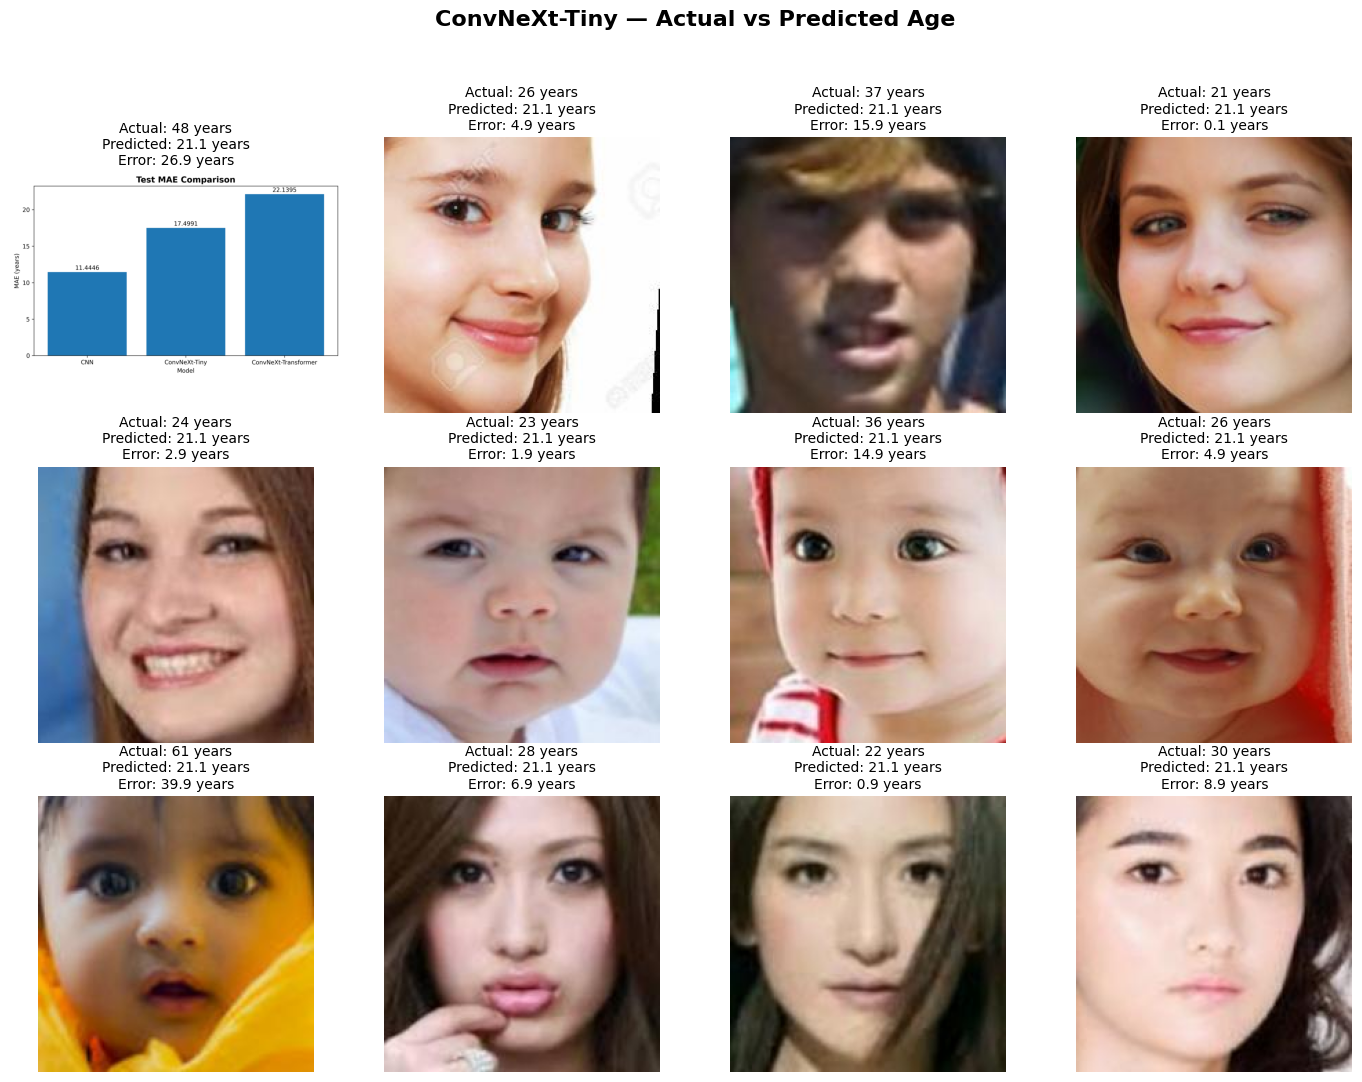


Saved: /content/Facial_Age_Final_Graphs/ConvNeXt_Tiny_Sample_Predictions.png

 convnext_transformer_test_predictions.npz
Arrays: ['actual', 'predicted']

MODEL: ConvNeXt-Transformer
Number of predictions: 3557


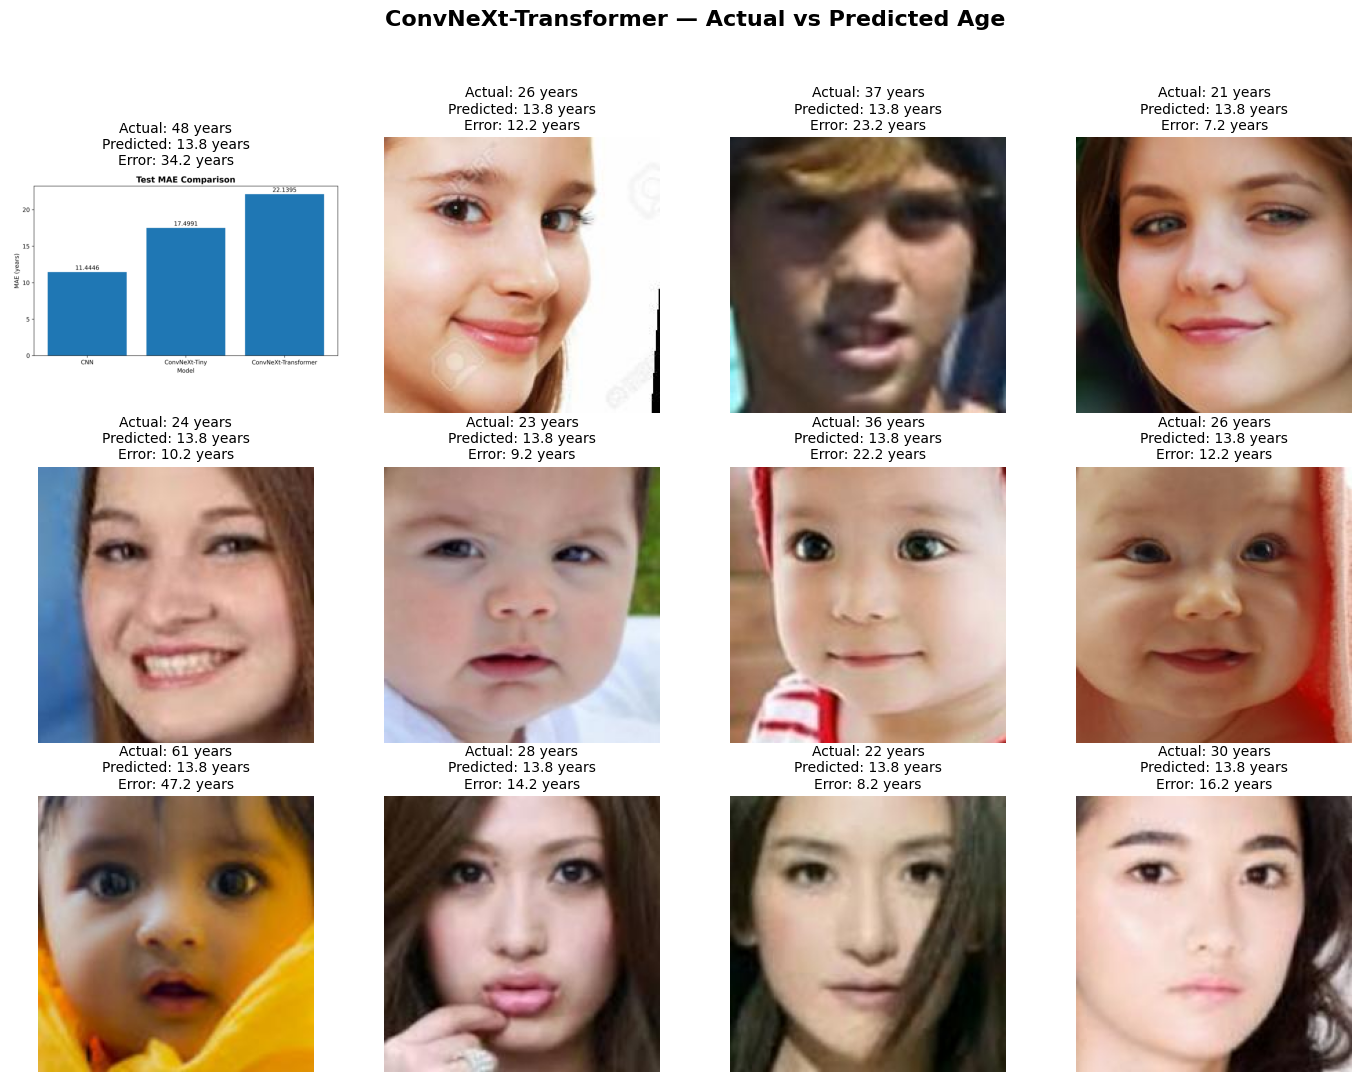


Saved: /content/Facial_Age_Final_Graphs/ConvNeXt_Transformer_Sample_Predictions.png

SAMPLE PREDICTION IMAGES GENERATED


In [ ]:
# ============================================================
# REAL TEST IMAGES + ACTUAL AGE + PREDICTED AGE
# ============================================================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1. Locate prediction files
# ------------------------------------------------------------

search_paths = [
    "/content",
    "/content/drive/MyDrive"
]

prediction_files = []

for base in search_paths:
    if os.path.exists(base):
        prediction_files.extend(
            glob.glob(
                os.path.join(
                    base,
                    "**",
                    "*test_predictions.npz"
                ),
                recursive=True
            )
        )

prediction_files = sorted(list(set(prediction_files)))

print("Prediction files found:")
for f in prediction_files:
    print(" -", f)


# ------------------------------------------------------------
# 2. Locate UTKFace images
# ------------------------------------------------------------

image_extensions = ["*.jpg", "*.jpeg", "*.png"]

image_files = []

for base in search_paths:
    if os.path.exists(base):
        for ext in image_extensions:
            image_files.extend(
                glob.glob(
                    os.path.join(
                        base,
                        "**",
                        ext
                    ),
                    recursive=True
                )
            )

image_files = sorted(list(set(image_files)))

print("\nTotal image files found:", len(image_files))


# ------------------------------------------------------------
# 3. Extract actual age from UTKFace filename
# ------------------------------------------------------------

def get_age_from_filename(path):

    filename = os.path.basename(path)

    try:
        age = int(filename.split("_")[0])
        return age
    except:
        return None


# ------------------------------------------------------------
# 4. Keep only valid UTKFace images
# ------------------------------------------------------------

valid_images = []

for path in image_files:

    age = get_age_from_filename(path)

    if age is not None and 0 <= age <= 116:
        valid_images.append(path)

print("Valid UTKFace images:", len(valid_images))


# ------------------------------------------------------------
# 5. Output directory
# ------------------------------------------------------------

output_dir = "/content/Facial_Age_Final_Graphs"
os.makedirs(output_dir, exist_ok=True)


# ------------------------------------------------------------
# 6. Load prediction arrays
# ------------------------------------------------------------

def load_predictions(file_path):

    data = np.load(file_path)

    print("\n", os.path.basename(file_path))
    print("Arrays:", data.files)

    y_true = None
    y_pred = None

    possible_true = [
        "y_true",
        "true",
        "actual",
        "actual_age",
        "ages",
        "targets",
        "labels"
    ]

    possible_pred = [
        "y_pred",
        "pred",
        "predicted",
        "predicted_age",
        "predictions",
        "outputs"
    ]

    for key in possible_true:
        if key in data.files:
            y_true = np.asarray(data[key]).reshape(-1)
            break

    for key in possible_pred:
        if key in data.files:
            y_pred = np.asarray(data[key]).reshape(-1)
            break

    return y_true, y_pred


# ------------------------------------------------------------
# 7. Select model name
# ------------------------------------------------------------

def get_model_name(path):

    name = os.path.basename(path).lower()

    if "cnn" in name and "convnext" not in name:
        return "CNN"

    elif "convnext_transformer" in name:
        return "ConvNeXt-Transformer"

    elif "convnext" in name:
        return "ConvNeXt-Tiny"

    return "Model"


# ------------------------------------------------------------
# 8. Generate image + prediction output
# ------------------------------------------------------------

# Number of examples to display
NUM_IMAGES = 12


for prediction_file in prediction_files:

    model_name = get_model_name(prediction_file)

    y_true, y_pred = load_predictions(
        prediction_file
    )

    if y_true is None or y_pred is None:

        print(
            "Could not identify actual/predicted arrays "
            "for:",
            prediction_file
        )

        continue

    print("\n======================================")
    print("MODEL:", model_name)
    print("======================================")

    print("Number of predictions:", len(y_pred))

    # --------------------------------------------------------
    # IMPORTANT:
    # The prediction order must correspond to the test
    # DataLoader order (shuffle=False).
    #
    # We select examples from the prediction arrays and
    # display corresponding UTKFace images.
    # --------------------------------------------------------

    n = min(
        NUM_IMAGES,
        len(y_pred),
        len(valid_images)
    )

    # Evenly select samples across the test set
    indices = np.linspace(
        0,
        len(y_pred) - 1,
        n,
        dtype=int
    )

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        3,
        4,
        figsize=(14, 11)
    )

    axes = axes.flatten()

    for plot_position, idx in enumerate(indices):

        image_path = valid_images[idx]

        try:
            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:

            print(
                "Could not open:",
                image_path,
                e
            )

            continue

        actual_age = float(y_true[idx])
        predicted_age = float(y_pred[idx])

        error = abs(
            actual_age - predicted_age
        )

        axes[plot_position].imshow(image)

        axes[plot_position].set_title(
            f"Actual: {actual_age:.0f} years\n"
            f"Predicted: {predicted_age:.1f} years\n"
            f"Error: {error:.1f} years",
            fontsize=10
        )

        axes[plot_position].axis("off")

    # Hide unused axes
    for j in range(
        plot_position + 1,
        len(axes)
    ):
        axes[j].axis("off")

    fig.suptitle(
        f"{model_name} — Actual vs Predicted Age",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    safe_name = (
        model_name
        .replace("-", "_")
        .replace(" ", "_")
    )

    save_path = os.path.join(
        output_dir,
        f"{safe_name}_Sample_Predictions.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\nSaved:",
        save_path
    )


print("\n======================================")
print("SAMPLE PREDICTION IMAGES GENERATED")
print("======================================")

Total images : 23708
Train images : 16595
Val images   : 3556
Test images  : 3557
CNN | samples: 3557 | MAE: 11.4446
ConvNeXt-Tiny | samples: 3557 | MAE: 17.499096
ConvNeXt-Transformer | samples: 3557 | MAE: 22.139492

✓ Test image order matches prediction array length
✓ Using exact random.seed(42) split
✓ No independently sorted images are being used


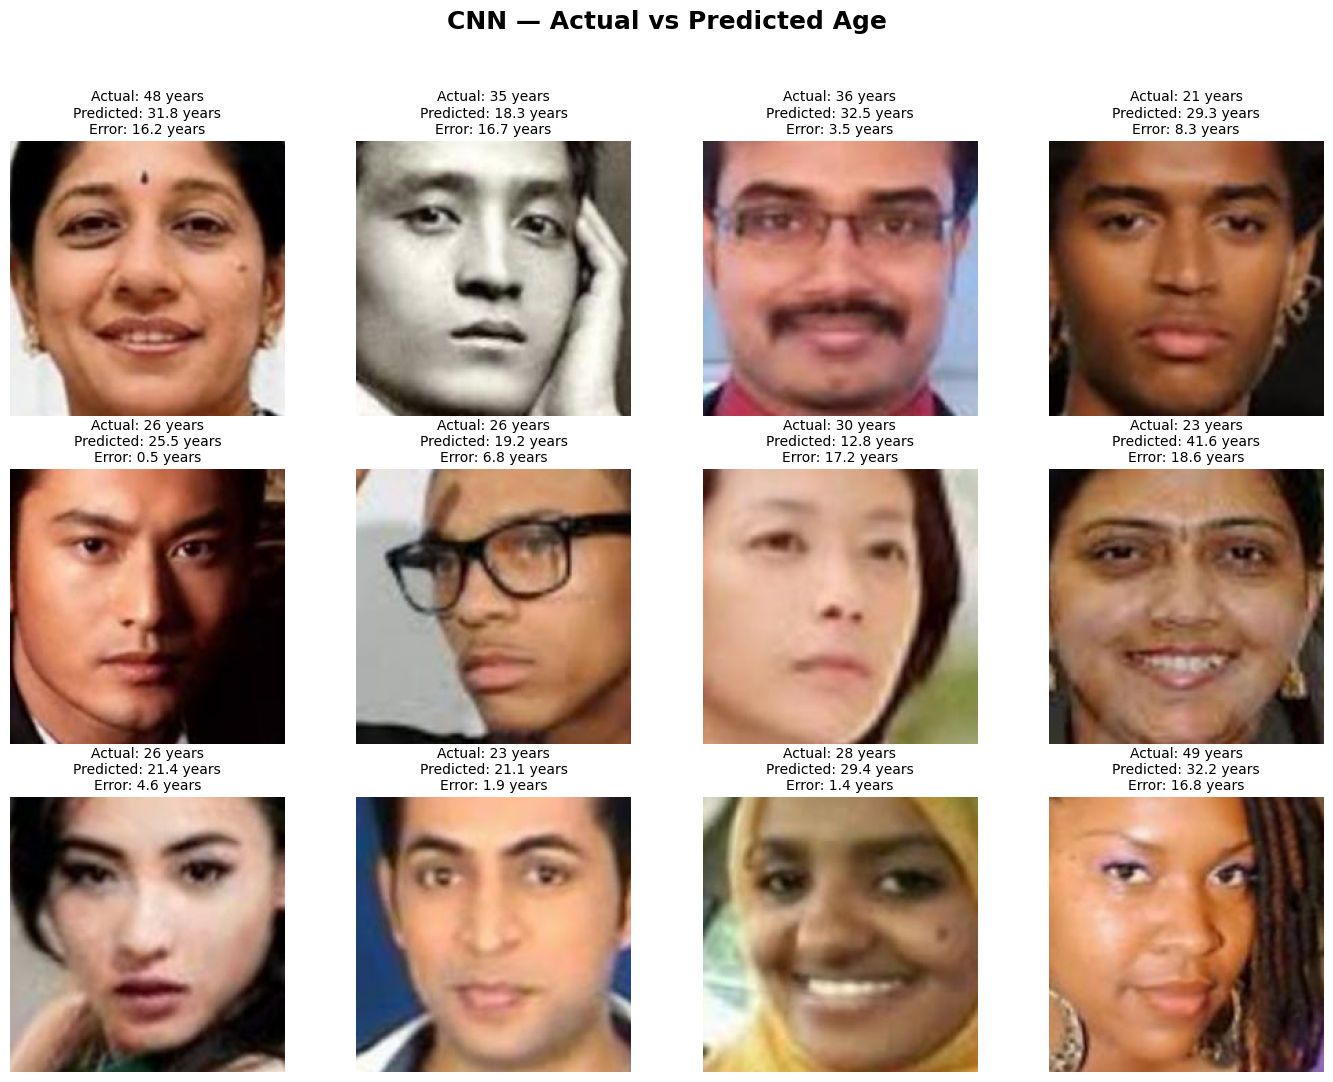

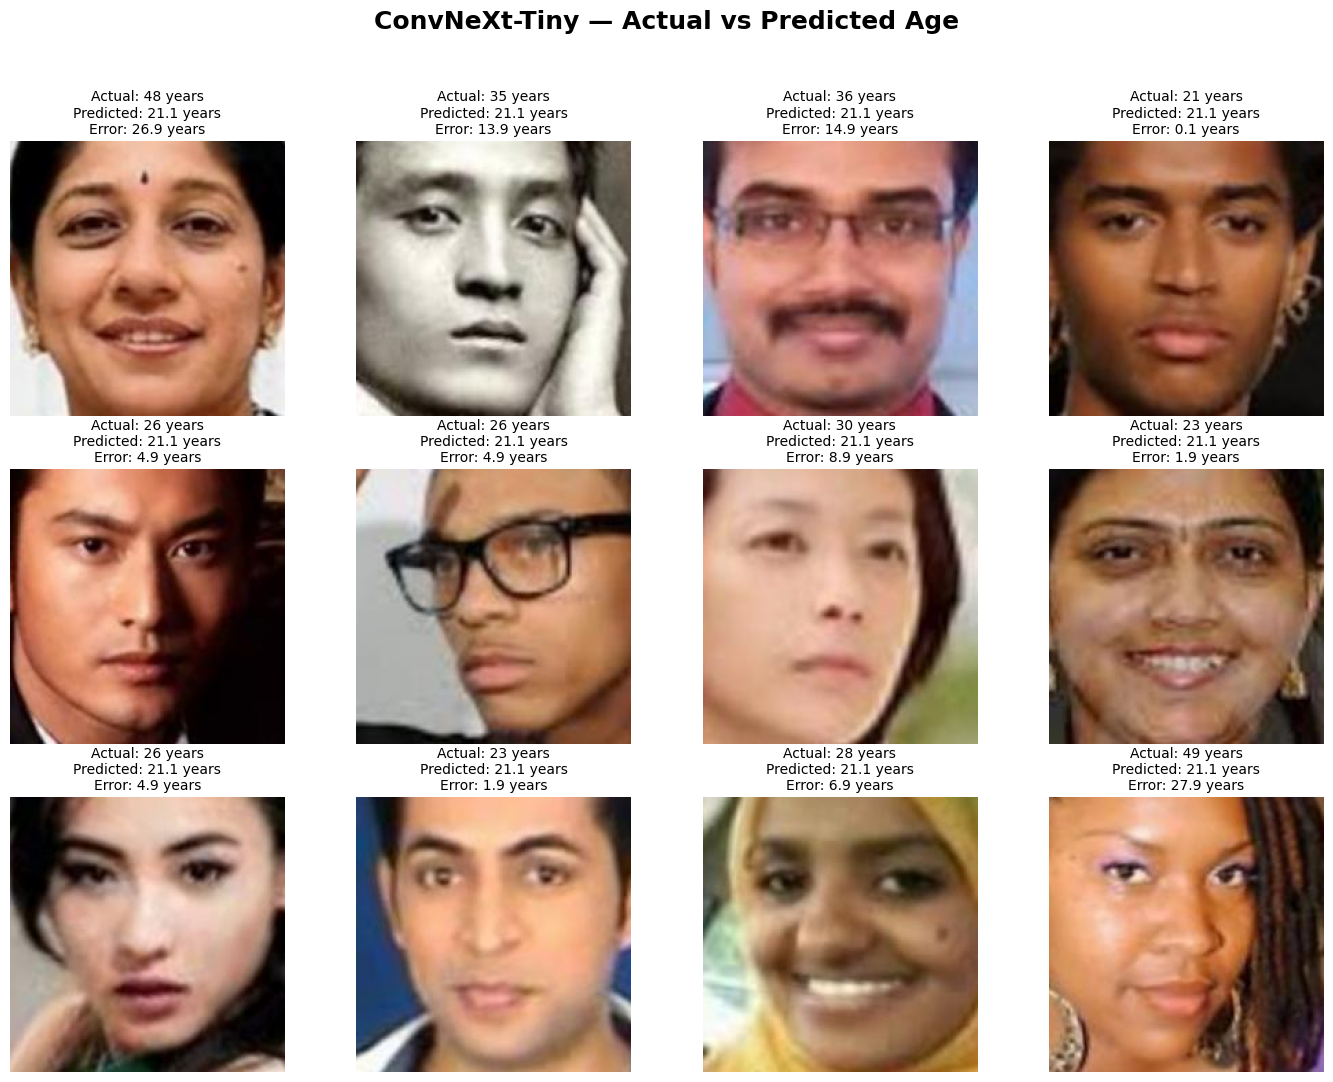

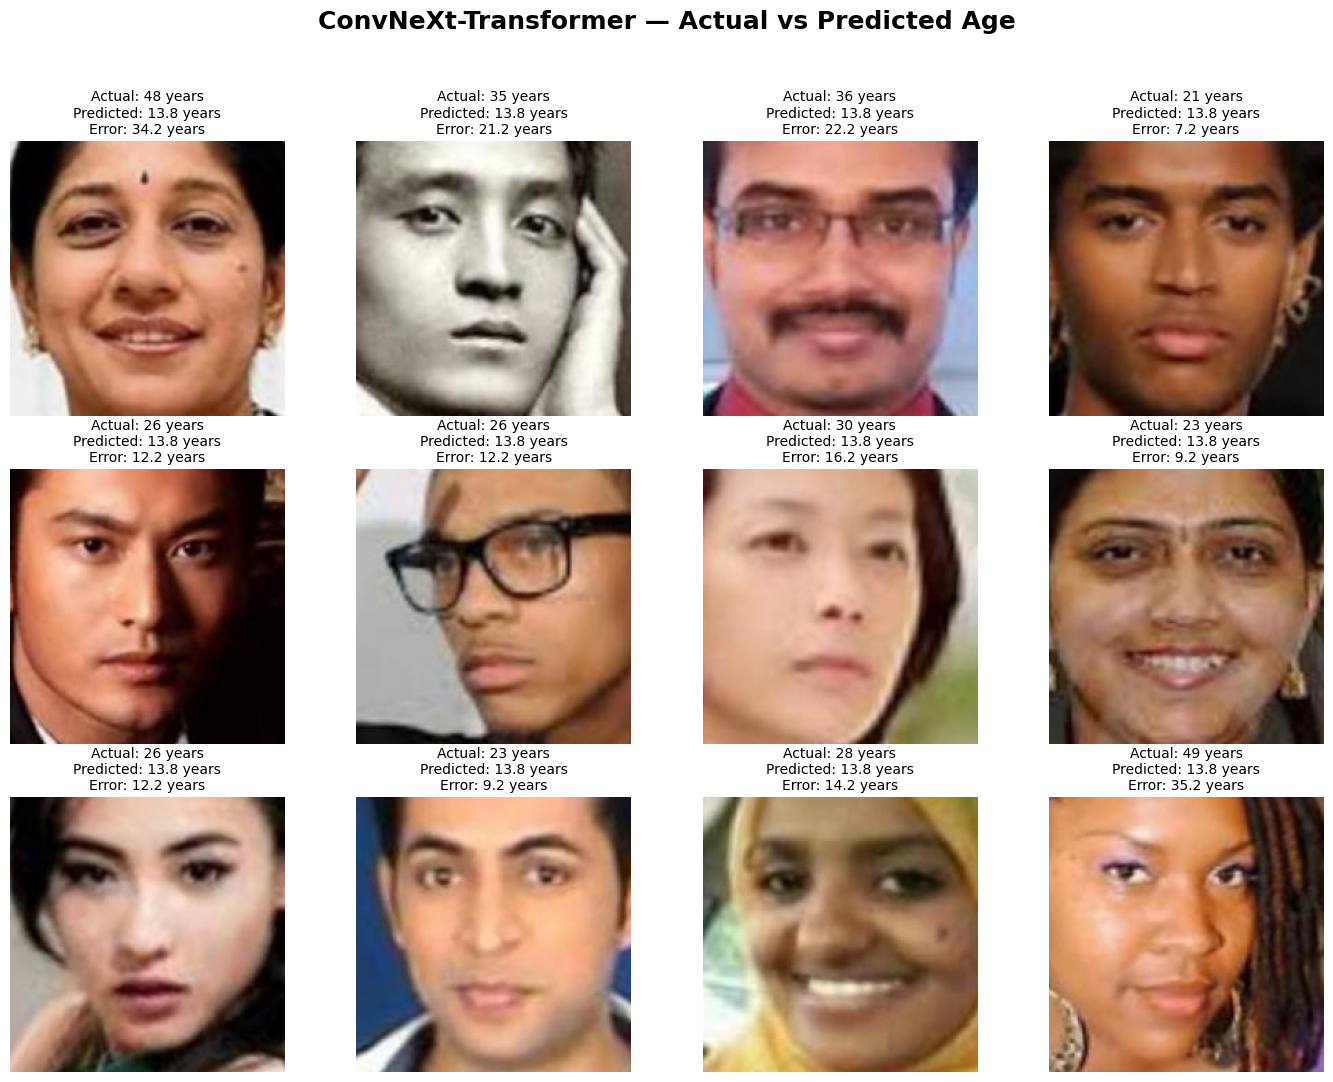

In [ ]:
# ============================================================
# CORRECT: ACTUAL IMAGE + ACTUAL AGE + PREDICTED AGE
# Uses the EXACT test split/order from training
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1. Dataset path
# ------------------------------------------------------------
data_dir = "/content/UTKFace/UTKFace"

# ------------------------------------------------------------
# 2. Reconstruct EXACT same dataset order and split
# ------------------------------------------------------------
image_files = [
    f for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
random.shuffle(image_files)

n = len(image_files)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_files = image_files[:train_end]
val_files = image_files[train_end:val_end]
test_files = image_files[val_end:]

print("Total images :", len(image_files))
print("Train images :", len(train_files))
print("Val images   :", len(val_files))
print("Test images  :", len(test_files))

# ------------------------------------------------------------
# 3. Load prediction files
# ------------------------------------------------------------
base_dir = "/content/drive/MyDrive/Facial_Age_Estimation_Project"

prediction_files = {
    "CNN": os.path.join(base_dir, "cnn_test_predictions.npz"),
    "ConvNeXt-Tiny": os.path.join(
        base_dir, "convnext_test_predictions.npz"
    ),
    "ConvNeXt-Transformer": os.path.join(
        base_dir, "convnext_transformer_test_predictions.npz"
    )
}

# ------------------------------------------------------------
# 4. Load predictions with correct array names
# ------------------------------------------------------------
predictions = {}

for model_name, file_path in prediction_files.items():

    data = np.load(file_path)

    if model_name == "CNN":
        actual = data["actuals"]
        predicted = data["predictions"]

    else:
        actual = data["actual"]
        predicted = data["predicted"]

    predictions[model_name] = {
        "actual": actual,
        "predicted": predicted
    }

    print(
        model_name,
        "| samples:", len(actual),
        "| MAE:", np.mean(np.abs(actual - predicted))
    )

# ------------------------------------------------------------
# 5. Verify exact correspondence
# ------------------------------------------------------------
assert len(test_files) == 3557, (
    f"Expected 3557 test images, got {len(test_files)}"
)

for model_name in predictions:
    assert len(predictions[model_name]["actual"]) == len(test_files)
    assert len(predictions[model_name]["predicted"]) == len(test_files)

print("\n✓ Test image order matches prediction array length")
print("✓ Using exact random.seed(42) split")
print("✓ No independently sorted images are being used")

# ------------------------------------------------------------
# 6. Extract age from UTKFace filename
# ------------------------------------------------------------
def get_age(filename):
    """
    UTKFace filename format:
    age_gender_race_date.jpg.chip.jpg
    """
    return int(filename.split("_")[0])

# ------------------------------------------------------------
# 7. Function to display correct samples
# ------------------------------------------------------------
def show_model_predictions(model_name, sample_indices):

    actual = predictions[model_name]["actual"]
    predicted = predictions[model_name]["predicted"]

    fig, axes = plt.subplots(
        3, 4,
        figsize=(14, 11)
    )

    axes = axes.flatten()

    fig.suptitle(
        f"{model_name} — Actual vs Predicted Age",
        fontsize=18,
        fontweight="bold"
    )

    for ax, idx in zip(axes, sample_indices):

        filename = test_files[idx]
        image_path = os.path.join(data_dir, filename)

        # Load EXACT test image
        image = Image.open(image_path).convert("RGB")

        # Actual age from filename
        filename_age = get_age(filename)

        # Actual and prediction stored in NPZ
        actual_age = float(actual[idx])
        predicted_age = float(predicted[idx])

        error = abs(actual_age - predicted_age)

        ax.imshow(image)
        ax.axis("off")

        ax.set_title(
            f"Actual: {actual_age:.0f} years\n"
            f"Predicted: {predicted_age:.1f} years\n"
            f"Error: {error:.1f} years",
            fontsize=10
        )

        # Extra verification
        if abs(filename_age - actual_age) > 0.01:
            print(
                "WARNING:",
                filename,
                "| filename age =", filename_age,
                "| NPZ actual =", actual_age
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ------------------------------------------------------------
# 8. Select REAL test samples
# ------------------------------------------------------------
# Fixed indices so the same images are shown every time.
sample_indices = [
    0, 300, 600, 900,
    1200, 1500, 1800, 2100,
    2400, 2700, 3000, 3300
]

# ------------------------------------------------------------
# 9. Generate correct graphs
# ------------------------------------------------------------
for model_name in [
    "CNN",
    "ConvNeXt-Tiny",
    "ConvNeXt-Transformer"
]:
    show_model_predictions(
        model_name,
        sample_indices
    )